# Undercast prediction - data prep and model training

In [80]:
import numpy as np
import glob
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

In [81]:
# Load and concatenate all CSVs
csv_dir = "/Users/lucasehinger/Library/CloudStorage/OneDrive-Personal/Documents/MIT/lucasehinger.github.io/files/weather/csv/ML/all/"
paths = glob.glob(os.path.join(csv_dir, "*_MtWashington.csv"))
random_state=23
if not paths:
    raise FileNotFoundError(f"No CSVs found in {csv_dir}")

dfs = []
for p in paths:
    tmp = pd.read_csv(p)
    fname = os.path.basename(p)
    date_part = fname.split("_", 1)[0]
    dt = pd.to_datetime(date_part, format="%Y-%m-%d", errors="coerce")
    tmp["month"] = dt.month
    tmp["day"] = dt.day
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(paths)} files, {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 589 files, 4487 rows, 63 columns


,fxx,cloud_top_hrrr,boundary_layer_cloud_layer,low_cloud_layer_percent_hrrr,middle_cloud_layer_percent_hrrr,high_cloud_layer_percent_hrrr,cloud_ceiling_m_hrrr,cloud_base_m_hrrr,cloud_top_pres_hrrr,cloud_base_pres_hrrr,...,tmp_2m_nam,rh_2m_nam,rh_925mb_nam,hpbl_surface_nam,hgt_0C_iso_nam,prate_surface_nam,apcp_surface_nam,is_undercast,month,day
0,2,-999.0,0.0,0.0,17.0,40.0,NaN,2278.649170,NaN,26400.0,...,290.089966,96.300003,98.0,453.279999,4384.479980,0.0,0.125,0.0,7,30
1,4,-999.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,289.640015,73.199997,59.0,190.000000,4276.319824,0.0,0.000,0.0,7,30
2,6,-999.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,290.690002,48.900002,37.0,112.080002,4239.262207,0.0,0.000,0.0,7,30
3,8,-999.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,290.790009,48.700001,46.0,36.880001,4070.468018,0.0,0.000,0.0,7,30
4,12,-999.0,0.0,0.0,0.0,92.0,NaN,1808.572144,NaN,28100.0,...,291.019989,72.699997,69.0,229.440002,3957.279785,0.0,0.000,0.0,7,30


In [ ]:
# %%
# Basic target/feature split
target_col = "is_undercast"
if target_col not in df.columns:
    raise KeyError(f"Target column '{target_col}' not found in data")

y = df[target_col]
X = df.drop(columns=[target_col])

# df = df[(df['fxx'] >= 2) & (df['fxx'] <= 8)].reset_index(drop=True)
# model_cols = [c for c in X.columns if any(s in c for s in ("_nam", "_hrrr", "_gfs")) or c in {"month", "day"}]
model_cols = [c for c in X.columns if c.endswith("_hrrr") or c in {"month", "day"}]

# Keep only columns that exist in X, then subset X
model_cols = [c for c in model_cols if c in X.columns]
X = X[model_cols].copy()
# print(f"Using {len(model_cols)} model columns, X shape: {X.shape}")


# Identify column types
cat_cols = [c for c in model_cols if X[c].dtype == "object"]
num_cols = [c for c in model_cols if X[c].dtype != "object"]
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns ({len(num_cols)}): {num_cols}")

Categorical columns (0): []
Numeric columns (24): ['cloud_top_hrrr', 'low_cloud_layer_percent_hrrr', 'middle_cloud_layer_percent_hrrr', 'high_cloud_layer_percent_hrrr', 'cloud_ceiling_m_hrrr', 'cloud_base_m_hrrr', 'cloud_top_pres_hrrr', 'cloud_base_pres_hrrr', 'cloud_top_hgt_hrrr', 'wind_10m_day_max_hrrr', 'tmp_500mb_hrrr', 'tmp_700mb_hrrr', 'tmp_850mb_hrrr', 'tmp_925mb_hrrr', 'tmp_1000mb_hrrr', 'tmp_2m_hrrr', 'rh_2m_hrrr', 'hpbl_surface_hrrr', 'hgt_0C_iso_hrrr', 'vis_surface_hrrr', 'prate_surface_hrrr', 'apcp_surface_hrrr', 'month', 'day']


In [84]:
# %%
# Preprocess: impute missing, one-hot encode categoricals, pass-through numerics
preprocess = make_column_transformer(
    (make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")), cat_cols),
    (make_pipeline(SimpleImputer(strategy="median")), num_cols),
)

model = GradientBoostingRegressor(random_state=random_state)

pipe = make_pipeline(preprocess, model)

# %%
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=random_state
)

pipe.fit(X_train, y_train)

# %%
# Evaluate
preds = pipe.predict(X_test)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"Test MAE: {mae:.4f}")
print(f"Test R2:  {r2:.4f}")

Test MAE: 0.0323
Test R2:  0.2167


In [85]:
# Inspect feature importances (approximate via model attributes after preprocessing)
# Note: OneHotEncoder expands categorical features, so names are transformed.

# Get feature names
cat_feature_names = []
if cat_cols:
    ohe = pipe.named_steps["columntransformer"].named_transformers_[0].named_steps["onehotencoder"]
    cat_feature_names = list(ohe.get_feature_names_out(cat_cols))

feature_names = cat_feature_names + num_cols

gb = pipe.named_steps["gradientboostingregressor"]
importances = gb.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

pd.DataFrame({
    "feature": np.array(feature_names)[top_idx],
    "importance": importances[top_idx],
})

,feature,importance
0,tmp_500mb_hrrr,0.210622
1,hpbl_surface_hrrr,0.105403
2,tmp_700mb_hrrr,0.097405
3,month,0.090550
4,day,0.085788
5,wind_10m_day_max_hrrr,0.078114
6,apcp_surface_hrrr,0.049430
7,tmp_2m_hrrr,0.044563
8,cloud_ceiling_m_hrrr,0.028785
9,cloud_top_hgt_hrrr,0.027572


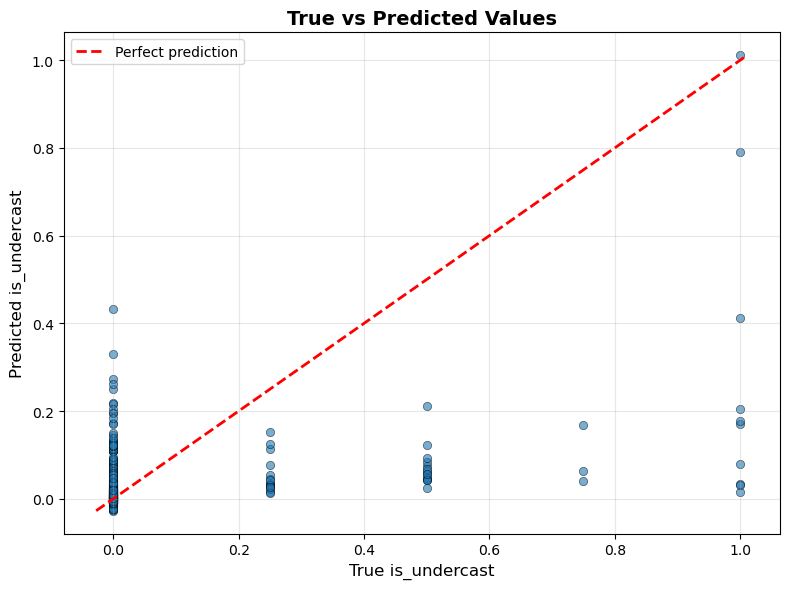

In [86]:
import matplotlib.pyplot as plt

# Scatter plot: true vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.6, edgecolors='k', linewidth=0.5)

# Add diagonal line for perfect predictions
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')

plt.xlabel('True is_undercast', fontsize=12)
plt.ylabel('Predicted is_undercast', fontsize=12)
plt.title('True vs Predicted Values', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
# Check class imbalance
print("True is_undercast distribution:")
print(y_test.value_counts(normalize=True))
print()

# Strategy 1: Use sample weights during training
# Weight positive examples inversely to their frequency
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight('balanced', y_train)

# Retrain with sample weights
pipe_weighted = make_pipeline(preprocess, GradientBoostingRegressor(random_state=random_state))
pipe_weighted.fit(X_train, y_train, gradientboostingregressor__sample_weight=sample_weights)

preds_weighted = pipe_weighted.predict(X_test)
mae_weighted = mean_absolute_error(y_test, preds_weighted)
r2_weighted = r2_score(y_test, preds_weighted)

print("=== With Sample Weights ===")
print(f"Test MAE: {mae_weighted:.4f} (was {mae:.4f})")
print(f"Test R2:  {r2_weighted:.4f} (was {r2:.4f})")
print()

# Strategy 2: Binarize and evaluate as classification
# Convert continuous targets to binary (0 or 1)
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score

y_test_binary = (y_test >= 0.5).astype(int)
y_train_binary = (y_train >= 0.5).astype(int)

# Find optimal threshold using ROC curve
fpr, tpr, thresholds = roc_curve(y_test_binary, preds_weighted)
roc_auc = auc(fpr, tpr)

# Find optimal threshold (Youden's index)
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

preds_binary_optimal = (preds_weighted >= optimal_threshold).astype(int)

precision = precision_score(y_test_binary, preds_binary_optimal, zero_division=0)
recall = recall_score(y_test_binary, preds_binary_optimal, zero_division=0)
f1 = f1_score(y_test_binary, preds_binary_optimal, zero_division=0)

print(f"=== Optimal Threshold: {optimal_threshold:.4f} ===")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {roc_auc:.4f}")

True is_undercast distribution:
is_undercast
0.00    0.968077
0.25    0.011878
0.50    0.010393
1.00    0.007424
0.75    0.002227
Name: proportion, dtype: float64

=== With Sample Weights ===
Test MAE: 0.1459 (was 0.0323)
Test R2:  -2.1937 (was 0.2167)

=== Optimal Threshold: 0.3611 ===
Precision: 0.1858
Recall:    0.7778
F1-Score:  0.3000
AUC-ROC:   0.9272


In [88]:
# Strategy 3: Oversample minority class using SMOTE
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# First, preprocess the data
X_train_preprocessed = preprocess.fit_transform(X_train)
X_test_preprocessed = preprocess.transform(X_test)

# Convert continuous target to binary for SMOTE
y_train_binary = (y_train >= 0.5).astype(int)

# Apply SMOTE to oversample minority class
print("Before SMOTE:")
print(pd.Series(y_train_binary).value_counts(normalize=True))
print()

smote = SMOTE(random_state=random_state, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_preprocessed, y_train_binary)

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts(normalize=True))
print()

# Train model on oversampled data
model_smote = GradientBoostingRegressor(random_state=random_state)
model_smote.fit(X_train_smote, y_train_smote)

preds_smote = model_smote.predict(X_test_preprocessed)
mae_smote = mean_absolute_error(y_test, preds_smote)
r2_smote = r2_score(y_test, preds_smote)

print("=== With SMOTE Oversampling ===")
print(f"Test MAE: {mae_smote:.4f} (original: {mae:.4f})")
print(f"Test R2:  {r2_smote:.4f} (original: {r2:.4f})")
print()

# Evaluate with optimal threshold
y_test_binary = (y_test >= 0.5).astype(int)
fpr_smote, tpr_smote, thresholds_smote = roc_curve(y_test_binary, preds_smote)
roc_auc_smote = auc(fpr_smote, tpr_smote)

optimal_idx_smote = (tpr_smote - fpr_smote).argmax()
optimal_threshold_smote = thresholds_smote[optimal_idx_smote]

preds_binary_smote = (preds_smote >= optimal_threshold_smote).astype(int)

precision_smote = precision_score(y_test_binary, preds_binary_smote, zero_division=0)
recall_smote = recall_score(y_test_binary, preds_binary_smote, zero_division=0)
f1_smote = f1_score(y_test_binary, preds_binary_smote, zero_division=0)

print(f"Optimal Threshold: {optimal_threshold_smote:.4f}")
print(f"Precision: {precision_smote:.4f}")
print(f"Recall:    {recall_smote:.4f}")
print(f"F1-Score:  {f1_smote:.4f}")
print(f"AUC-ROC:   {roc_auc_smote:.4f}")

Before SMOTE:
is_undercast
0    0.975796
1    0.024204
Name: proportion, dtype: float64

After SMOTE:
is_undercast
0    0.5
1    0.5
Name: proportion, dtype: float64

=== With SMOTE Oversampling ===
Test MAE: 0.1834 (original: 0.0323)
Test R2:  -3.9574 (original: 0.2167)

Optimal Threshold: 0.3893
Precision: 0.1214
Recall:    0.7778
F1-Score:  0.2100
AUC-ROC:   0.9042


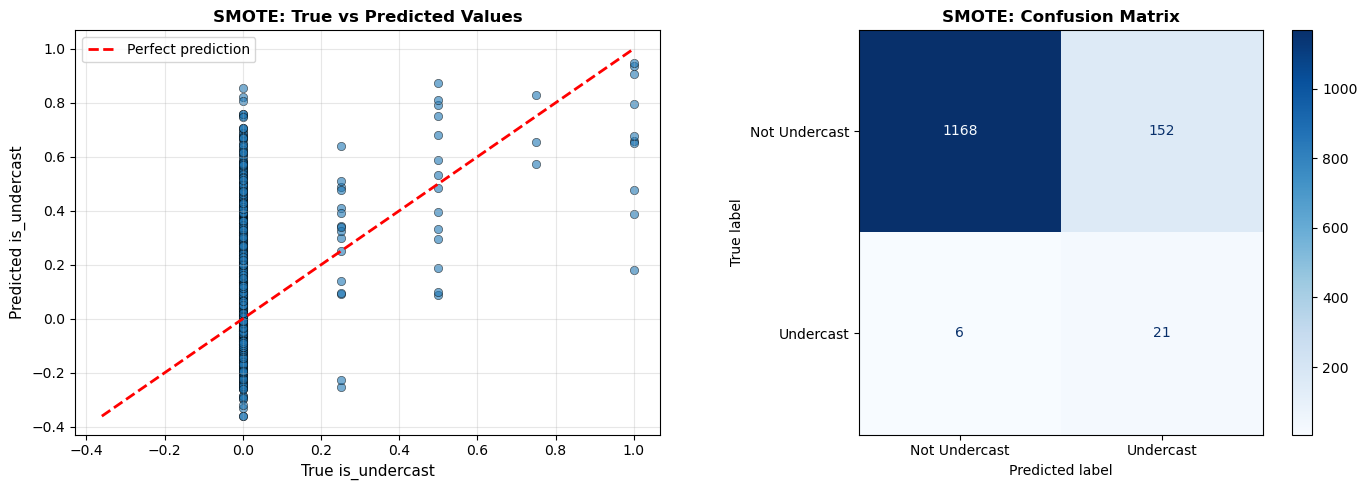


Confusion Matrix Breakdown:
True Negatives:  1168
False Positives: 152
False Negatives: 6
True Positives:  21


In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create figure with scatter plot and confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: true vs predicted values (SMOTE)
axes[0].scatter(y_test, preds_smote, alpha=0.6, edgecolors='k', linewidth=0.5)
min_val = min(y_test.min(), preds_smote.min())
max_val = max(y_test.max(), preds_smote.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('True is_undercast', fontsize=11)
axes[0].set_ylabel('Predicted is_undercast', fontsize=11)
axes[0].set_title('SMOTE: True vs Predicted Values', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test_binary, preds_binary_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Undercast', 'Undercast'])
disp.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('SMOTE: Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Dictionary to store results
results = {}
predictions_dict = {}

# Model 1: Logistic Regression
print("=" * 50)
print("Training Logistic Regression...")
print("=" * 50)
lr = LogisticRegression(max_iter=5000, solver='lbfgs', class_weight='balanced', random_state=random_state)
lr.fit(X_train_smote, y_train_smote)
preds_lr = lr.predict_proba(X_test_preprocessed)[:, 1]
preds_lr_binary = (preds_lr >= 0.5).astype(int)

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test_binary, preds_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
optimal_idx_lr = (tpr_lr - fpr_lr).argmax()
optimal_threshold_lr = thresholds_lr[optimal_idx_lr]
preds_lr_opt = (preds_lr >= optimal_threshold_lr).astype(int)

precision_lr = precision_score(y_test_binary, preds_lr_opt, zero_division=0)
recall_lr = recall_score(y_test_binary, preds_lr_opt, zero_division=0)
f1_lr = f1_score(y_test_binary, preds_lr_opt, zero_division=0)

results['Logistic Regression'] = {
    'Precision': precision_lr,
    'Recall': recall_lr,
    'F1-Score': f1_lr,
    'AUC-ROC': roc_auc_lr,
    'Threshold': optimal_threshold_lr
}
predictions_dict['Logistic Regression'] = preds_lr_opt

print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")
print(f"AUC-ROC:   {roc_auc_lr:.4f}\n")

# Model 2: Random Forest Classifier
print("=" * 50)
print("Training Random Forest Classifier...")
print("=" * 50)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=random_state, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)
preds_rf = rf.predict_proba(X_test_preprocessed)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_binary, preds_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
optimal_idx_rf = (tpr_rf - fpr_rf).argmax()
optimal_threshold_rf = thresholds_rf[optimal_idx_rf]
preds_rf_opt = (preds_rf >= optimal_threshold_rf).astype(int)

precision_rf = precision_score(y_test_binary, preds_rf_opt, zero_division=0)
recall_rf = recall_score(y_test_binary, preds_rf_opt, zero_division=0)
f1_rf = f1_score(y_test_binary, preds_rf_opt, zero_division=0)

results['Random Forest'] = {
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf,
    'AUC-ROC': roc_auc_rf,
    'Threshold': optimal_threshold_rf
}
predictions_dict['Random Forest'] = preds_rf_opt

print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")
print(f"AUC-ROC:   {roc_auc_rf:.4f}\n")

# Model 3: XGBoost Classifier
print("=" * 50)
print("Training XGBoost Classifier...")
print("=" * 50)
xgb = XGBClassifier(random_state=random_state, scale_pos_weight=(y_train_smote==0).sum()/(y_train_smote==1).sum(), n_jobs=-1, verbosity=0)
xgb.fit(X_train_smote, y_train_smote)
preds_xgb = xgb.predict_proba(X_test_preprocessed)[:, 1]

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test_binary, preds_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
optimal_idx_xgb = (tpr_xgb - fpr_xgb).argmax()
optimal_threshold_xgb = thresholds_xgb[optimal_idx_xgb]
preds_xgb_opt = (preds_xgb >= optimal_threshold_xgb).astype(int)

precision_xgb = precision_score(y_test_binary, preds_xgb_opt, zero_division=0)
recall_xgb = recall_score(y_test_binary, preds_xgb_opt, zero_division=0)
f1_xgb = f1_score(y_test_binary, preds_xgb_opt, zero_division=0)

results['XGBoost'] = {
    'Precision': precision_xgb,
    'Recall': recall_xgb,
    'F1-Score': f1_xgb,
    'AUC-ROC': roc_auc_xgb,
    'Threshold': optimal_threshold_xgb
}
predictions_dict['XGBoost'] = preds_xgb_opt

print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1-Score:  {f1_xgb:.4f}")
print(f"AUC-ROC:   {roc_auc_xgb:.4f}\n")

# Add SMOTE Gradient Boosting to comparison
results['Gradient Boosting (SMOTE)'] = {
    'Precision': precision_smote,
    'Recall': recall_smote,
    'F1-Score': f1_smote,
    'AUC-ROC': roc_auc_smote,
    'Threshold': optimal_threshold_smote
}
predictions_dict['Gradient Boosting (SMOTE)'] = preds_binary_smote

# Create comparison table
comparison_df = pd.DataFrame(results).T
print("=" * 50)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 50)
print(comparison_df.round(4))
print("\n" + "=" * 50)
print("Best Models by Metric:")
print("=" * 50)
print(f"Best Precision: {comparison_df['Precision'].idxmax()} ({comparison_df['Precision'].max():.4f})")
print(f"Best Recall:    {comparison_df['Recall'].idxmax()} ({comparison_df['Recall'].max():.4f})")
print(f"Best F1-Score:  {comparison_df['F1-Score'].idxmax()} ({comparison_df['F1-Score'].max():.4f})")
print(f"Best AUC-ROC:   {comparison_df['AUC-ROC'].idxmax()} ({comparison_df['AUC-ROC'].max():.4f})")

Training Logistic Regression...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Precision: 0.0653
Recall:    0.8148
F1-Score:  0.1209
AUC-ROC:   0.8594

Training Random Forest Classifier...
Precision: 0.2907
Recall:    0.9259
F1-Score:  0.4425
AUC-ROC:   0.9749

Training XGBoost Classifier...
Precision: 0.3140
Recall:    1.0000
F1-Score:  0.4779
AUC-ROC:   0.9904

MODEL PERFORMANCE COMPARISON
                           Precision  Recall  F1-Score  AUC-ROC  Threshold
Logistic Regression           0.0653  0.8148    0.1209   0.8594     0.5593
Random Forest                 0.2907  0.9259    0.4425   0.9749     0.2800
XGBoost                       0.3140  1.0000    0.4779   0.9904     0.0508
Gradient Boosting (SMOTE)     0.1214  0.7778    0.2100   0.9042     0.3893

Best Models by Metric:
Best Precision: XGBoost (0.3140)
Best Recall:    XGBoost (1.0000)
Best F1-Score:  XGBoost (0.4779)
Best AUC-ROC:   XGBoost (0.9904)


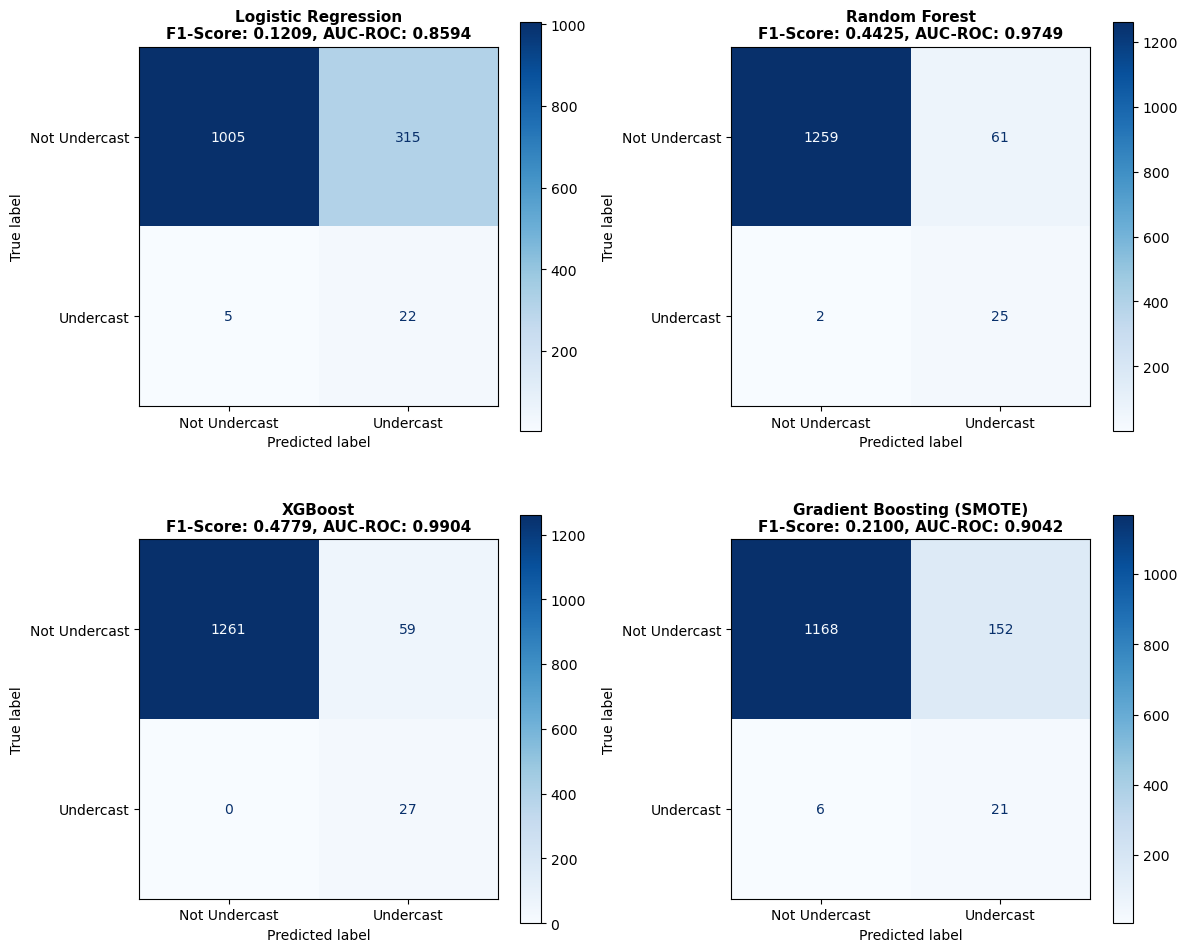


DETAILED CONFUSION MATRIX BREAKDOWN FOR ALL MODELS

Logistic Regression:
  True Negatives:  1005
  False Positives: 315
  False Negatives: 5
  True Positives:  22
  Sensitivity (Recall): 0.8148
  Specificity: 0.7614

Random Forest:
  True Negatives:  1259
  False Positives: 61
  False Negatives: 2
  True Positives:  25
  Sensitivity (Recall): 0.9259
  Specificity: 0.9538

XGBoost:
  True Negatives:  1261
  False Positives: 59
  False Negatives: 0
  True Positives:  27
  Sensitivity (Recall): 1.0000
  Specificity: 0.9553

Gradient Boosting (SMOTE):
  True Negatives:  1168
  False Positives: 152
  False Negatives: 6
  True Positives:  21
  Sensitivity (Recall): 0.7778
  Specificity: 0.8848


In [91]:
# Display confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting (SMOTE)']

for idx, (model_name, ax) in enumerate(zip(model_names, axes)):
    preds = predictions_dict[model_name]
    cm = confusion_matrix(y_test_binary, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Undercast', 'Undercast'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'{model_name}\nF1-Score: {results[model_name]["F1-Score"]:.4f}, AUC-ROC: {results[model_name]["AUC-ROC"]:.4f}', 
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed breakdown for each model
print("\n" + "=" * 70)
print("DETAILED CONFUSION MATRIX BREAKDOWN FOR ALL MODELS")
print("=" * 70)

for model_name in model_names:
    preds = predictions_dict[model_name]
    cm = confusion_matrix(y_test_binary, preds)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n{model_name}:")
    print(f"  True Negatives:  {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives:  {tp}")
    print(f"  Sensitivity (Recall): {tp/(tp+fn):.4f}" if (tp+fn) > 0 else "  Sensitivity: N/A")
    print(f"  Specificity: {tn/(tn+fp):.4f}" if (tn+fp) > 0 else "  Specificity: N/A")

Total features after preprocessing: 24

TOP 15 MOST IMPORTANT FEATURES FOR EACH MODEL

Logistic Regression:
----------------------------------------------------------------------
   1. apcp_surface_hrrr                             0.124734
   2. month                                         0.084817
   3. rh_2m_hrrr                                    0.075894
   4. wind_10m_day_max_hrrr                         0.073534
   5. tmp_500mb_hrrr                                0.045524
   6. tmp_700mb_hrrr                                0.041307
   7. tmp_2m_hrrr                                   0.029225
   8. tmp_925mb_hrrr                                0.019986
   9. tmp_1000mb_hrrr                               0.019047
  10. low_cloud_layer_percent_hrrr                  0.018996
  11. day                                           0.013783
  12. tmp_850mb_hrrr                                0.013383
  13. high_cloud_layer_percent_hrrr                 0.011351
  14. middle_cloud_layer_per

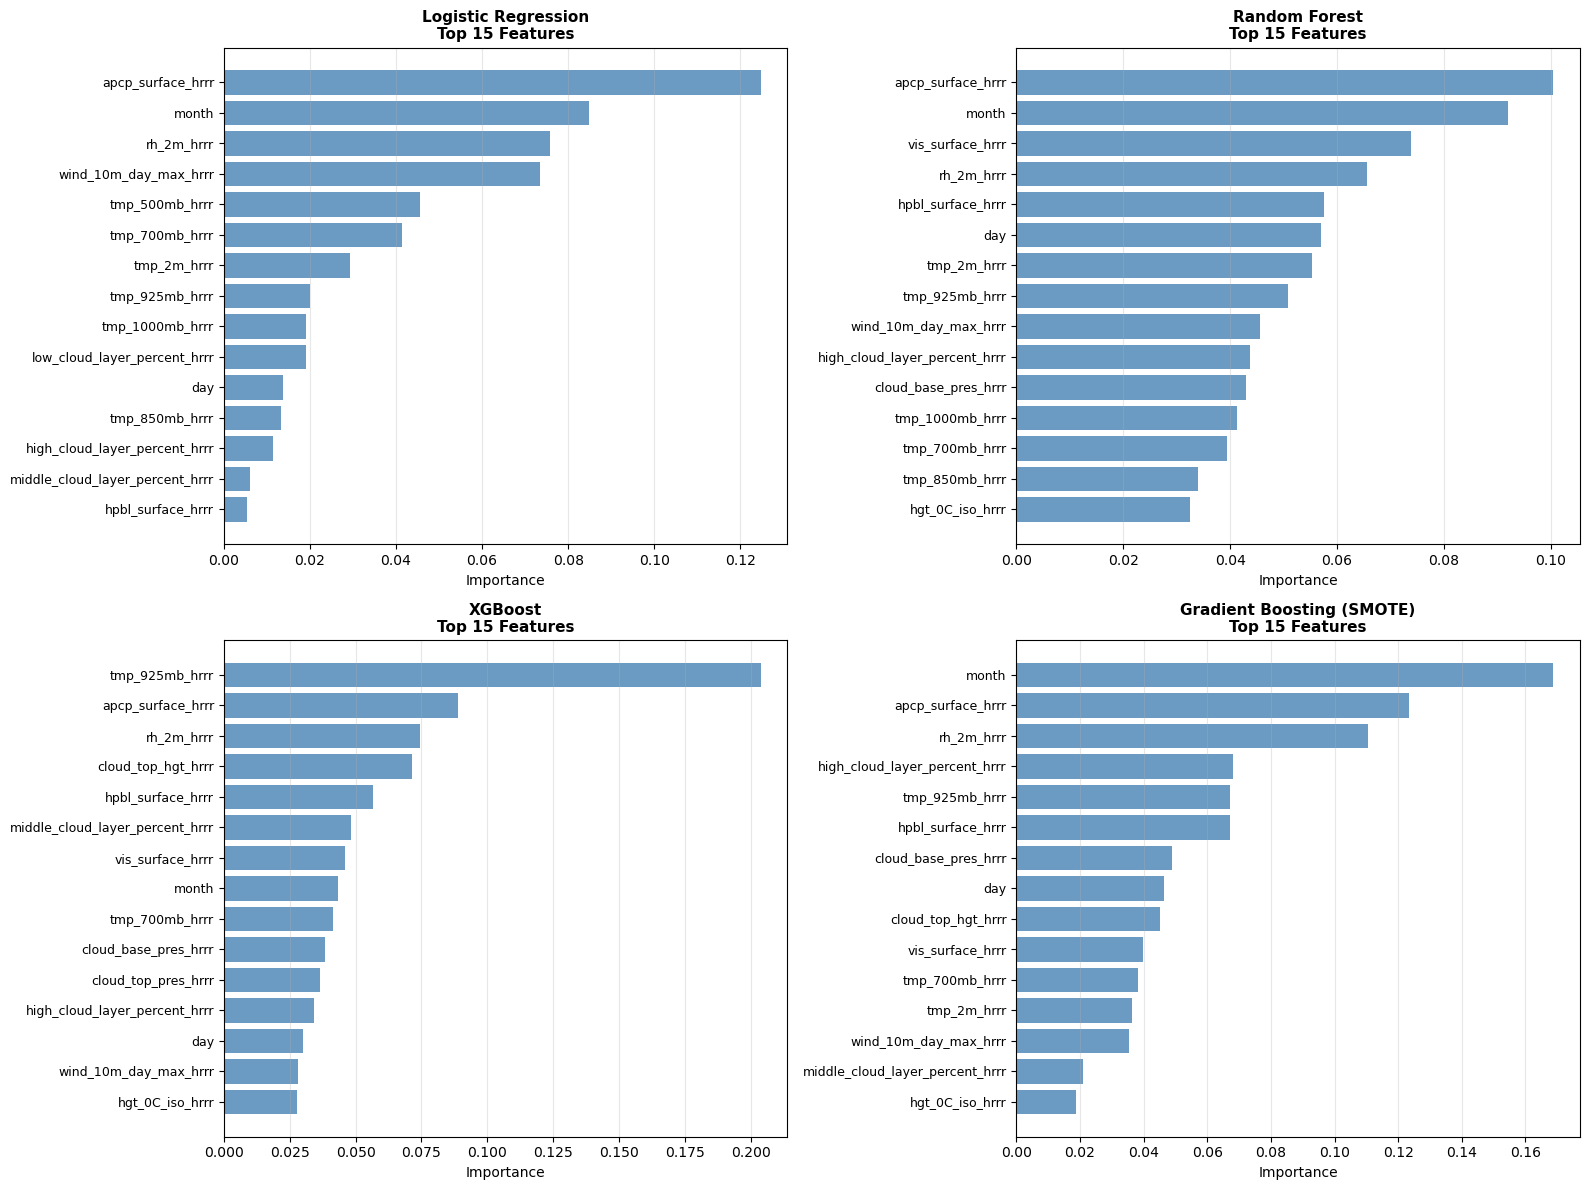

In [92]:
# Get feature names from preprocessing pipeline
cat_feature_names = []
if cat_cols:
    ohe_step = preprocess.named_transformers_['pipeline-1'].named_steps['onehotencoder']
    cat_feature_names = list(ohe_step.get_feature_names_out(cat_cols))

all_feature_names = cat_feature_names + num_cols

print(f"Total features after preprocessing: {len(all_feature_names)}\n")

# Dictionary to store feature importances
feature_importance_data = {}

# Model 1: Logistic Regression (use absolute coefficients)
lr_coef = np.abs(lr.coef_[0])
top_lr_idx = np.argsort(lr_coef)[::-1][:15]
feature_importance_data['Logistic Regression'] = pd.DataFrame({
    'Feature': np.array(all_feature_names)[top_lr_idx],
    'Importance': lr_coef[top_lr_idx]
})

# Model 2: Random Forest
rf_importances = rf.feature_importances_
top_rf_idx = np.argsort(rf_importances)[::-1][:15]
feature_importance_data['Random Forest'] = pd.DataFrame({
    'Feature': np.array(all_feature_names)[top_rf_idx],
    'Importance': rf_importances[top_rf_idx]
})

# Model 3: XGBoost
xgb_importances = xgb.feature_importances_
top_xgb_idx = np.argsort(xgb_importances)[::-1][:15]
feature_importance_data['XGBoost'] = pd.DataFrame({
    'Feature': np.array(all_feature_names)[top_xgb_idx],
    'Importance': xgb_importances[top_xgb_idx]
})

# Model 4: Gradient Boosting (SMOTE)
gb_importances = model_smote.feature_importances_
top_gb_idx = np.argsort(gb_importances)[::-1][:15]
feature_importance_data['Gradient Boosting (SMOTE)'] = pd.DataFrame({
    'Feature': np.array(all_feature_names)[top_gb_idx],
    'Importance': gb_importances[top_gb_idx]
})

# Display feature importances for each model
print("=" * 70)
print("TOP 15 MOST IMPORTANT FEATURES FOR EACH MODEL")
print("=" * 70)

for model_name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting (SMOTE)']:
    print(f"\n{model_name}:")
    print("-" * 70)
    df_imp = feature_importance_data[model_name]
    for idx, row in df_imp.iterrows():
        print(f"  {idx+1:2d}. {row['Feature']:45s} {row['Importance']:.6f}")

# Visualize feature importances
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, model_name in enumerate(['Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting (SMOTE)']):
    df_imp = feature_importance_data[model_name]
    ax = axes[idx]
    
    ax.barh(range(len(df_imp)), df_imp['Importance'], color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(df_imp)))
    ax.set_yticklabels(df_imp['Feature'], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Importance', fontsize=10)
    ax.set_title(f'{model_name}\nTop 15 Features', fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

ERROR COUNTS BY MODEL

Logistic Regression:
  Correct:         1027
  False Positives: 315
  False Negatives: 5
  Total Errors:    320

Random Forest:
  Correct:         1284
  False Positives: 61
  False Negatives: 2
  Total Errors:    63

XGBoost:
  Correct:         1288
  False Positives: 59
  False Negatives: 0
  Total Errors:    59

Gradient Boosting (SMOTE):
  Correct:         1189
  False Positives: 152
  False Negatives: 6
  Total Errors:    158

ERROR OVERLAP ANALYSIS

False Positive Overlap (same samples incorrectly predicted as undercast):
----------------------------------------------------------------------
Logistic Regression            & Random Forest                 :   46 shared ( 14.6% of Logistic Regression FPs)
Logistic Regression            & XGBoost                       :   45 shared ( 14.3% of Logistic Regression FPs)
Logistic Regression            & Gradient Boosting (SMOTE)     :  108 shared ( 34.3% of Logistic Regression FPs)
Random Forest                  & 

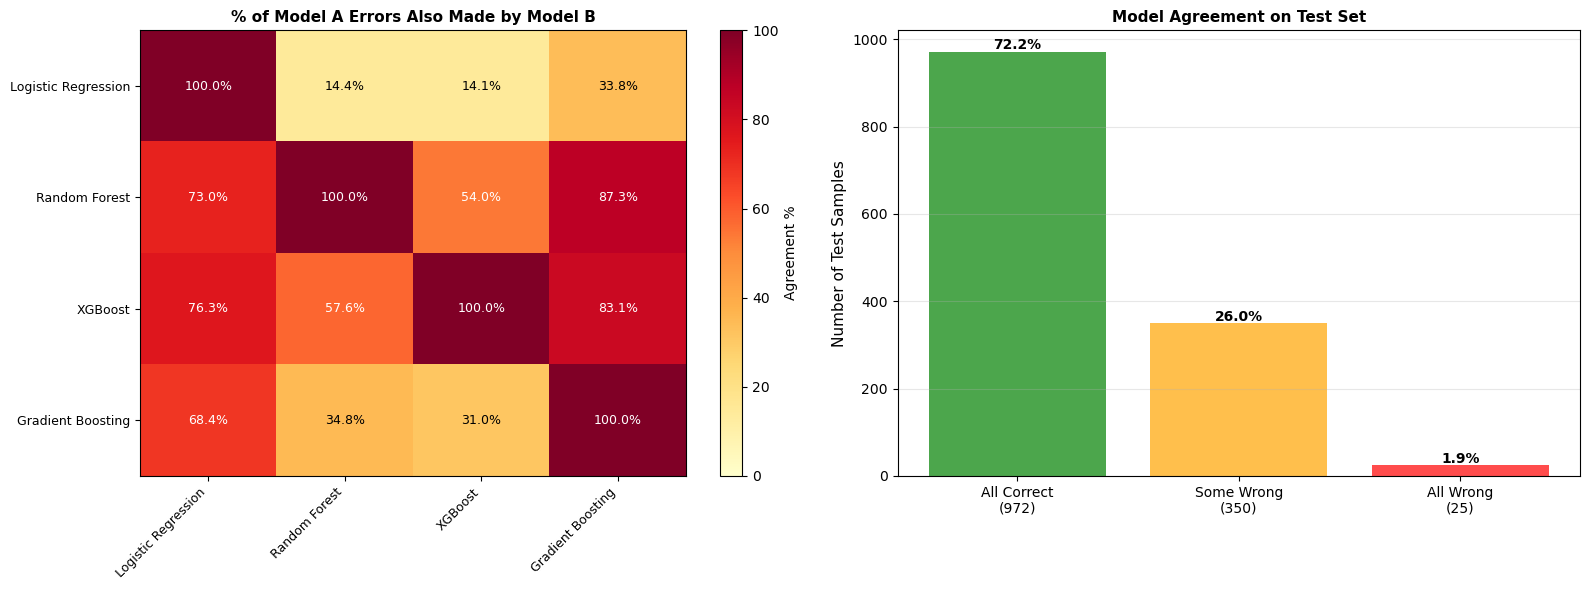


SAMPLES WHERE MODELS DISAGREE MOST

Found 350 samples where models disagree

Example disagreements (showing first 10):
----------------------------------------------------------------------

Sample 14 (True label: Not Undercast):
  ✗ Logistic Regression           : Undercast       (False Positive)
  ✓ Random Forest                 : Not Undercast   (Correct)
  ✗ XGBoost                       : Undercast       (False Positive)
  ✗ Gradient Boosting (SMOTE)     : Undercast       (False Positive)

Sample 18 (True label: Not Undercast):
  ✗ Logistic Regression           : Undercast       (False Positive)
  ✓ Random Forest                 : Not Undercast   (Correct)
  ✓ XGBoost                       : Not Undercast   (Correct)
  ✓ Gradient Boosting (SMOTE)     : Not Undercast   (Correct)

Sample 21 (True label: Not Undercast):
  ✗ Logistic Regression           : Undercast       (False Positive)
  ✓ Random Forest                 : Not Undercast   (Correct)
  ✓ XGBoost                       

In [93]:
# Analyze error overlap between models
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting (SMOTE)']

# Create dataframe to track predictions and errors for each model
error_analysis = pd.DataFrame({
    'True_Label': y_test_binary.values
})

for model_name in model_names:
    preds = predictions_dict[model_name]
    error_analysis[f'{model_name}_Pred'] = preds
    error_analysis[f'{model_name}_Correct'] = (preds == y_test_binary.values).astype(int)
    error_analysis[f'{model_name}_Error_Type'] = 'Correct'
    
    # Mark error types
    fp_mask = (preds == 1) & (y_test_binary.values == 0)
    fn_mask = (preds == 0) & (y_test_binary.values == 1)
    error_analysis.loc[fp_mask, f'{model_name}_Error_Type'] = 'False Positive'
    error_analysis.loc[fn_mask, f'{model_name}_Error_Type'] = 'False Negative'

# Count total errors by type for each model
print("=" * 70)
print("ERROR COUNTS BY MODEL")
print("=" * 70)
for model_name in model_names:
    error_counts = error_analysis[f'{model_name}_Error_Type'].value_counts()
    total_errors = len(error_analysis) - error_counts.get('Correct', 0)
    print(f"\n{model_name}:")
    print(f"  Correct:         {error_counts.get('Correct', 0)}")
    print(f"  False Positives: {error_counts.get('False Positive', 0)}")
    print(f"  False Negatives: {error_counts.get('False Negative', 0)}")
    print(f"  Total Errors:    {total_errors}")

# Analyze error overlap
print("\n" + "=" * 70)
print("ERROR OVERLAP ANALYSIS")
print("=" * 70)

# For each pair of models, count how many errors overlap
from itertools import combinations

print("\nFalse Positive Overlap (same samples incorrectly predicted as undercast):")
print("-" * 70)
for model1, model2 in combinations(model_names, 2):
    fp1 = set(error_analysis[error_analysis[f'{model1}_Error_Type'] == 'False Positive'].index)
    fp2 = set(error_analysis[error_analysis[f'{model2}_Error_Type'] == 'False Positive'].index)
    overlap = fp1 & fp2
    overlap_pct = 100 * len(overlap) / max(len(fp1), 1) if len(fp1) > 0 else 0
    print(f"{model1:30s} & {model2:30s}: {len(overlap):4d} shared ({overlap_pct:5.1f}% of {model1} FPs)")

print("\nFalse Negative Overlap (same samples incorrectly predicted as not undercast):")
print("-" * 70)
for model1, model2 in combinations(model_names, 2):
    fn1 = set(error_analysis[error_analysis[f'{model1}_Error_Type'] == 'False Negative'].index)
    fn2 = set(error_analysis[error_analysis[f'{model2}_Error_Type'] == 'False Negative'].index)
    overlap = fn1 & fn2
    overlap_pct = 100 * len(overlap) / max(len(fn1), 1) if len(fn1) > 0 else 0
    print(f"{model1:30s} & {model2:30s}: {len(overlap):4d} shared ({overlap_pct:5.1f}% of {model1} FNs)")

# Create heatmap showing error agreement
print("\n" + "=" * 70)
print("ERROR AGREEMENT MATRIX")
print("=" * 70)

error_agreement = np.zeros((len(model_names), len(model_names)))
for i, model1 in enumerate(model_names):
    for j, model2 in enumerate(model_names):
        if i == j:
            error_agreement[i, j] = 100.0
        else:
            errors1 = set(error_analysis[error_analysis[f'{model1}_Correct'] == 0].index)
            errors2 = set(error_analysis[error_analysis[f'{model2}_Correct'] == 0].index)
            if len(errors1) > 0:
                overlap_pct = 100 * len(errors1 & errors2) / len(errors1)
                error_agreement[i, j] = overlap_pct

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of error agreement
im1 = axes[0].imshow(error_agreement, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
axes[0].set_xticks(range(len(model_names)))
axes[0].set_yticks(range(len(model_names)))
axes[0].set_xticklabels([name.replace(' (SMOTE)', '') for name in model_names], rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels([name.replace(' (SMOTE)', '') for name in model_names], fontsize=9)
axes[0].set_title('% of Model A Errors Also Made by Model B', fontsize=11, fontweight='bold')

# Add text annotations
for i in range(len(model_names)):
    for j in range(len(model_names)):
        text = axes[0].text(j, i, f'{error_agreement[i, j]:.1f}%',
                           ha="center", va="center", color="black" if error_agreement[i, j] < 50 else "white", fontsize=9)

plt.colorbar(im1, ax=axes[0], label='Agreement %')

# Count unique vs shared errors
all_correct = error_analysis[[f'{m}_Correct' for m in model_names]].sum(axis=1) == len(model_names)
any_error = error_analysis[[f'{m}_Correct' for m in model_names]].sum(axis=1) < len(model_names)
all_error = error_analysis[[f'{m}_Correct' for m in model_names]].sum(axis=1) == 0

counts = [
    all_correct.sum(),
    (any_error & ~all_error).sum(),
    all_error.sum()
]
labels = [
    f'All Correct\n({counts[0]})',
    f'Some Wrong\n({counts[1]})',
    f'All Wrong\n({counts[2]})'
]

axes[1].bar(range(3), counts, color=['green', 'orange', 'red'], alpha=0.7)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(labels, fontsize=10)
axes[1].set_ylabel('Number of Test Samples', fontsize=11)
axes[1].set_title('Model Agreement on Test Set', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for i, (count, label) in enumerate(zip(counts, labels)):
    pct = 100 * count / len(error_analysis)
    axes[1].text(i, count + 5, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Show examples where models disagree most
print("\n" + "=" * 70)
print("SAMPLES WHERE MODELS DISAGREE MOST")
print("=" * 70)

# Find samples where exactly half are wrong
error_analysis['num_correct'] = error_analysis[[f'{m}_Correct' for m in model_names]].sum(axis=1)
disagree_samples = error_analysis[error_analysis['num_correct'].isin([1, 2, 3])]

if len(disagree_samples) > 0:
    print(f"\nFound {len(disagree_samples)} samples where models disagree")
    print("\nExample disagreements (showing first 10):")
    print("-" * 70)
    
    for idx, row in disagree_samples.head(10).iterrows():
        print(f"\nSample {idx} (True label: {'Undercast' if row['True_Label'] == 1 else 'Not Undercast'}):")
        for model_name in model_names:
            pred = 'Undercast' if row[f'{model_name}_Pred'] == 1 else 'Not Undercast'
            error_type = row[f'{model_name}_Error_Type']
            symbol = '✓' if error_type == 'Correct' else '✗'
            print(f"  {symbol} {model_name:30s}: {pred:15s} ({error_type})")
else:
    print("\nAll models agree on all predictions!")

DECISION THRESHOLD TUNING FOR XGBOOST

RECOMMENDED THRESHOLDS FOR DIFFERENT OBJECTIVES

1. BEST F1-SCORE (balanced precision/recall):
   Threshold: 0.6136
   Precision: 0.8000
   Recall:    0.5926
   F1-Score:  0.6809
   FP: 4, FN: 11

2. BEST PRECISION (minimize false alarms, recall >= 50%):
   Threshold: 0.8045
   Precision: 0.8750
   Recall:    0.5185
   F1-Score:  0.6512
   FP: 2, FN: 13

3. BEST RECALL (catch all undercasts, precision >= 10%):
   Threshold: 0.0500
   Precision: 0.3140
   Recall:    1.0000
   F1-Score:  0.4779
   FP: 59, FN: 0

4. CURRENT (Youden's Index from ROC):
   Threshold: 0.0508
   Precision: 0.3140
   Recall:    1.0000
   F1-Score:  0.4779


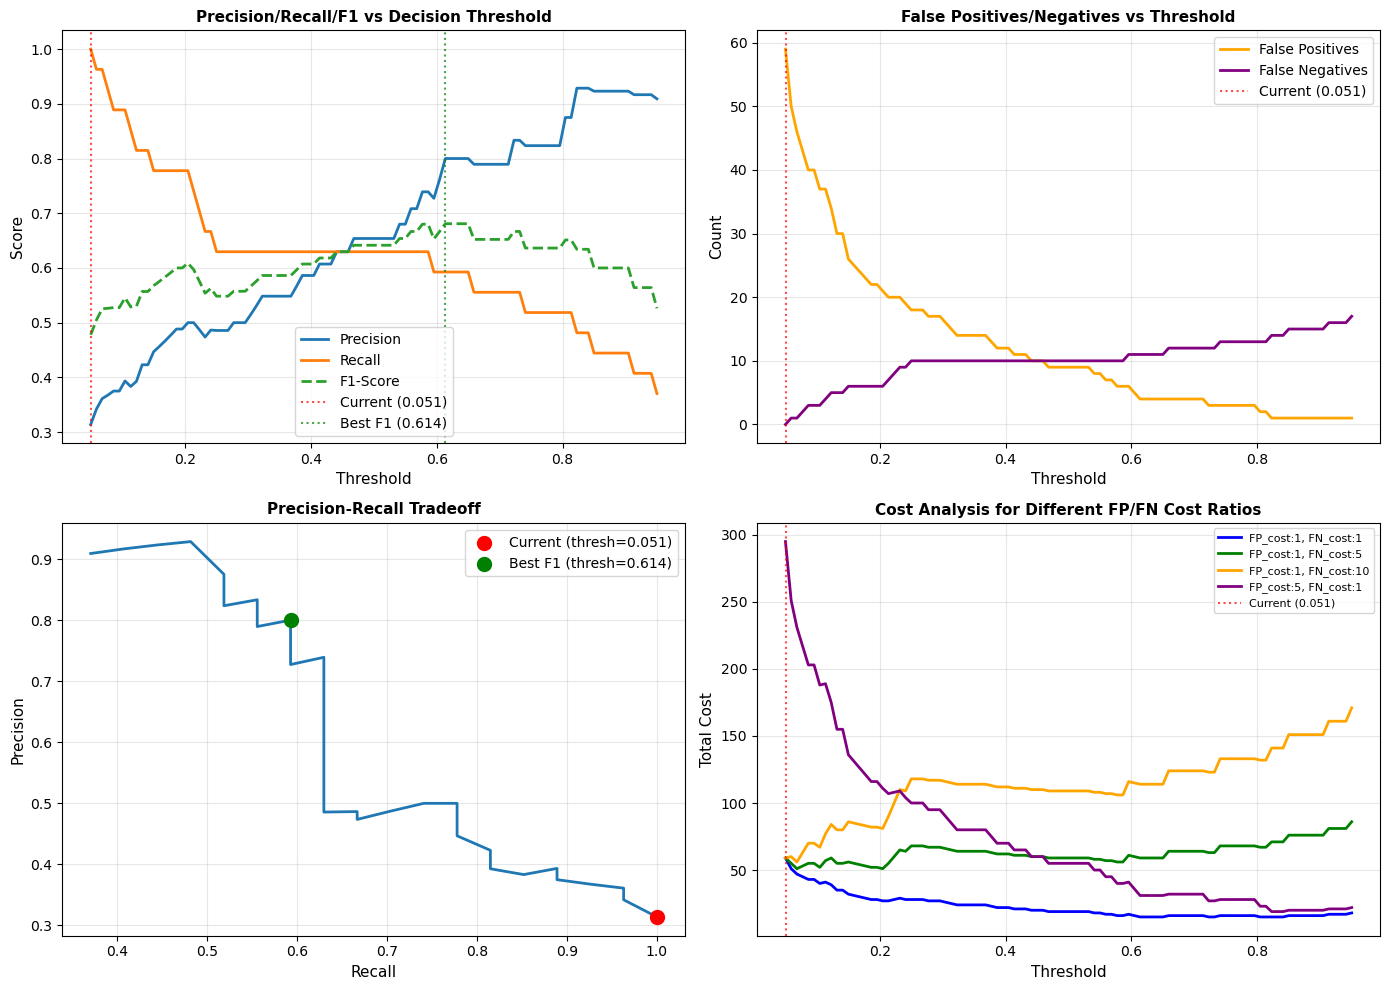

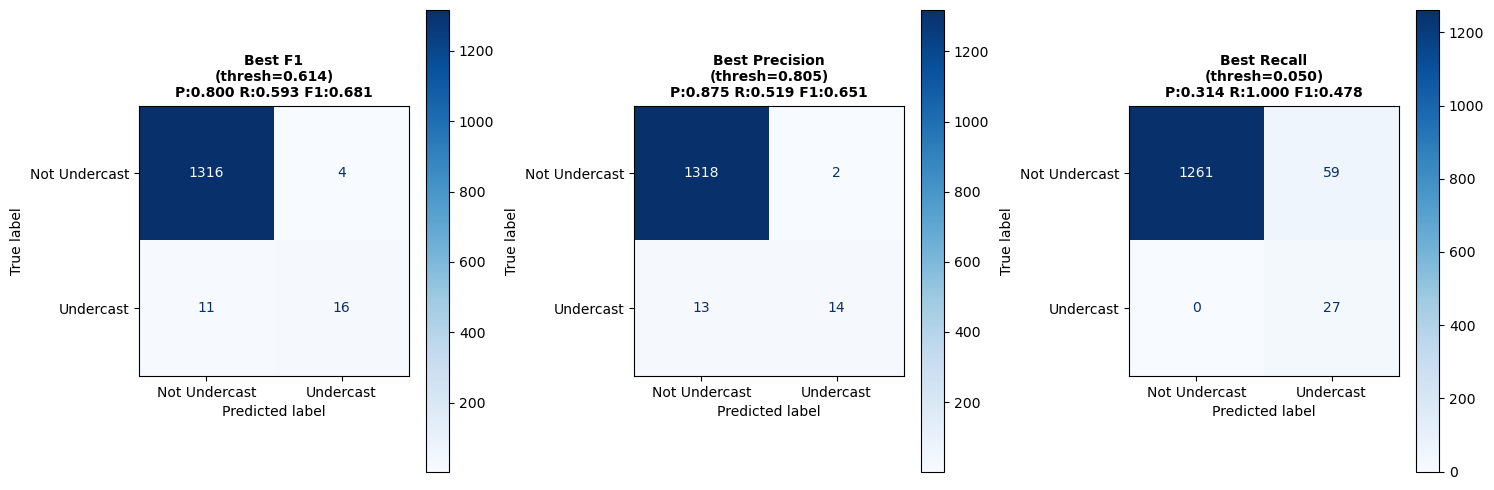


GUIDANCE FOR CHOOSING A THRESHOLD

1. **Safety-critical** (never miss an undercast):
   → Use BEST RECALL threshold (low threshold)
   → You'll get many false alarms, but won't miss undercasts

2. **Resource-limited** (can't respond to many alerts):
   → Use BEST PRECISION threshold (high threshold)
   → Fewer alerts, but you'll miss some undercasts

3. **Balanced** (equal importance):
   → Use BEST F1 threshold
   → Good compromise between catching undercasts and limiting false alarms

4. **Custom costs** (specific FP/FN costs):
   → Look at the cost analysis plot above
   → Find the threshold that minimizes your specific cost function


In [94]:
# Decision Threshold Tuning for XGBoost
# Much better approach than hyperparameter tuning for imbalanced data!

print("=" * 70)
print("DECISION THRESHOLD TUNING FOR XGBOOST")
print("=" * 70)

# Use original XGBoost probability predictions
threshold_range = np.linspace(0.05, 0.95, 100)

# Store metrics for each threshold
threshold_results = []

for thresh in threshold_range:
    preds_at_thresh = (preds_xgb >= thresh).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test_binary, preds_at_thresh).ravel()
    
    precision = precision_score(y_test_binary, preds_at_thresh, zero_division=0)
    recall = recall_score(y_test_binary, preds_at_thresh, zero_division=0)
    f1 = f1_score(y_test_binary, preds_at_thresh, zero_division=0)
    
    threshold_results.append({
        'threshold': thresh,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    })

threshold_df = pd.DataFrame(threshold_results)

# Find best thresholds for different objectives
best_f1_idx = threshold_df['f1_score'].idxmax()
best_precision_idx = threshold_df[threshold_df['recall'] >= 0.5]['precision'].idxmax() if any(threshold_df['recall'] >= 0.5) else 0
best_recall_idx = threshold_df[threshold_df['precision'] >= 0.1]['recall'].idxmax() if any(threshold_df['precision'] >= 0.1) else 0

print("\n" + "=" * 70)
print("RECOMMENDED THRESHOLDS FOR DIFFERENT OBJECTIVES")
print("=" * 70)

print(f"\n1. BEST F1-SCORE (balanced precision/recall):")
print(f"   Threshold: {threshold_df.loc[best_f1_idx, 'threshold']:.4f}")
print(f"   Precision: {threshold_df.loc[best_f1_idx, 'precision']:.4f}")
print(f"   Recall:    {threshold_df.loc[best_f1_idx, 'recall']:.4f}")
print(f"   F1-Score:  {threshold_df.loc[best_f1_idx, 'f1_score']:.4f}")
print(f"   FP: {threshold_df.loc[best_f1_idx, 'fp']:.0f}, FN: {threshold_df.loc[best_f1_idx, 'fn']:.0f}")

print(f"\n2. BEST PRECISION (minimize false alarms, recall >= 50%):")
print(f"   Threshold: {threshold_df.loc[best_precision_idx, 'threshold']:.4f}")
print(f"   Precision: {threshold_df.loc[best_precision_idx, 'precision']:.4f}")
print(f"   Recall:    {threshold_df.loc[best_precision_idx, 'recall']:.4f}")
print(f"   F1-Score:  {threshold_df.loc[best_precision_idx, 'f1_score']:.4f}")
print(f"   FP: {threshold_df.loc[best_precision_idx, 'fp']:.0f}, FN: {threshold_df.loc[best_precision_idx, 'fn']:.0f}")

print(f"\n3. BEST RECALL (catch all undercasts, precision >= 10%):")
print(f"   Threshold: {threshold_df.loc[best_recall_idx, 'threshold']:.4f}")
print(f"   Precision: {threshold_df.loc[best_recall_idx, 'precision']:.4f}")
print(f"   Recall:    {threshold_df.loc[best_recall_idx, 'recall']:.4f}")
print(f"   F1-Score:  {threshold_df.loc[best_recall_idx, 'f1_score']:.4f}")
print(f"   FP: {threshold_df.loc[best_recall_idx, 'fp']:.0f}, FN: {threshold_df.loc[best_recall_idx, 'fn']:.0f}")

print(f"\n4. CURRENT (Youden's Index from ROC):")
print(f"   Threshold: {optimal_threshold_xgb:.4f}")
print(f"   Precision: {precision_xgb:.4f}")
print(f"   Recall:    {recall_xgb:.4f}")
print(f"   F1-Score:  {f1_xgb:.4f}")

# Visualize threshold impact
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Precision/Recall vs Threshold
axes[0, 0].plot(threshold_df['threshold'], threshold_df['precision'], label='Precision', linewidth=2)
axes[0, 0].plot(threshold_df['threshold'], threshold_df['recall'], label='Recall', linewidth=2)
axes[0, 0].plot(threshold_df['threshold'], threshold_df['f1_score'], label='F1-Score', linewidth=2, linestyle='--')
axes[0, 0].axvline(optimal_threshold_xgb, color='red', linestyle=':', alpha=0.7, label=f'Current ({optimal_threshold_xgb:.3f})')
axes[0, 0].axvline(threshold_df.loc[best_f1_idx, 'threshold'], color='green', linestyle=':', alpha=0.7, label=f'Best F1 ({threshold_df.loc[best_f1_idx, "threshold"]:.3f})')
axes[0, 0].set_xlabel('Threshold', fontsize=11)
axes[0, 0].set_ylabel('Score', fontsize=11)
axes[0, 0].set_title('Precision/Recall/F1 vs Decision Threshold', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: False Positives/Negatives vs Threshold
axes[0, 1].plot(threshold_df['threshold'], threshold_df['fp'], label='False Positives', linewidth=2, color='orange')
axes[0, 1].plot(threshold_df['threshold'], threshold_df['fn'], label='False Negatives', linewidth=2, color='purple')
axes[0, 1].axvline(optimal_threshold_xgb, color='red', linestyle=':', alpha=0.7, label=f'Current ({optimal_threshold_xgb:.3f})')
axes[0, 1].set_xlabel('Threshold', fontsize=11)
axes[0, 1].set_ylabel('Count', fontsize=11)
axes[0, 1].set_title('False Positives/Negatives vs Threshold', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Precision-Recall Curve
axes[1, 0].plot(threshold_df['recall'], threshold_df['precision'], linewidth=2)
axes[1, 0].scatter(recall_xgb, precision_xgb, color='red', s=100, zorder=5, label=f'Current (thresh={optimal_threshold_xgb:.3f})')
axes[1, 0].scatter(threshold_df.loc[best_f1_idx, 'recall'], threshold_df.loc[best_f1_idx, 'precision'], 
                   color='green', s=100, zorder=5, label=f'Best F1 (thresh={threshold_df.loc[best_f1_idx, "threshold"]:.3f})')
axes[1, 0].set_xlabel('Recall', fontsize=11)
axes[1, 0].set_ylabel('Precision', fontsize=11)
axes[1, 0].set_title('Precision-Recall Tradeoff', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cost analysis (assuming different costs for FP and FN)
# Let's try a few cost ratios
cost_ratios = [(1, 1), (1, 5), (1, 10), (5, 1)]
colors = ['blue', 'green', 'orange', 'purple']

for (fp_cost, fn_cost), color in zip(cost_ratios, colors):
    total_cost = threshold_df['fp'] * fp_cost + threshold_df['fn'] * fn_cost
    axes[1, 1].plot(threshold_df['threshold'], total_cost, label=f'FP_cost:{fp_cost}, FN_cost:{fn_cost}', 
                    linewidth=2, color=color)
    
axes[1, 1].axvline(optimal_threshold_xgb, color='red', linestyle=':', alpha=0.7, label=f'Current ({optimal_threshold_xgb:.3f})')
axes[1, 1].set_xlabel('Threshold', fontsize=11)
axes[1, 1].set_ylabel('Total Cost', fontsize=11)
axes[1, 1].set_title('Cost Analysis for Different FP/FN Cost Ratios', fontsize=11, fontweight='bold')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show confusion matrices for different threshold choices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

threshold_choices = [
    (best_f1_idx, f'Best F1\n(thresh={threshold_df.loc[best_f1_idx, "threshold"]:.3f})'),
    (best_precision_idx, f'Best Precision\n(thresh={threshold_df.loc[best_precision_idx, "threshold"]:.3f})'),
    (best_recall_idx, f'Best Recall\n(thresh={threshold_df.loc[best_recall_idx, "threshold"]:.3f})')
]

for ax, (idx, title) in zip(axes, threshold_choices):
    thresh = threshold_df.loc[idx, 'threshold']
    preds_at_thresh = (preds_xgb >= thresh).astype(int)
    cm = confusion_matrix(y_test_binary, preds_at_thresh)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Undercast', 'Undercast'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    
    p = threshold_df.loc[idx, 'precision']
    r = threshold_df.loc[idx, 'recall']
    f1 = threshold_df.loc[idx, 'f1_score']
    ax.set_title(f'{title}\nP:{p:.3f} R:{r:.3f} F1:{f1:.3f}', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("GUIDANCE FOR CHOOSING A THRESHOLD")
print("=" * 70)
print("\n1. **Safety-critical** (never miss an undercast):")
print("   → Use BEST RECALL threshold (low threshold)")
print("   → You'll get many false alarms, but won't miss undercasts")
print("\n2. **Resource-limited** (can't respond to many alerts):")
print("   → Use BEST PRECISION threshold (high threshold)")
print("   → Fewer alerts, but you'll miss some undercasts")
print("\n3. **Balanced** (equal importance):")
print("   → Use BEST F1 threshold")
print("   → Good compromise between catching undercasts and limiting false alarms")
print("\n4. **Custom costs** (specific FP/FN costs):")
print("   → Look at the cost analysis plot above")
print("   → Find the threshold that minimizes your specific cost function")

DECISION THRESHOLD TUNING FOR RANDOM FOREST

RECOMMENDED THRESHOLDS FOR RANDOM FOREST

1. BEST F1-SCORE (balanced precision/recall):
   Threshold: 0.4591
   Precision: 0.5429
   Recall:    0.7037
   F1-Score:  0.6129
   FP: 16, FN: 8

2. BEST PRECISION (minimize false alarms, recall >= 50%):
   Threshold: 0.5318
   Precision: 0.5833
   Recall:    0.5185
   F1-Score:  0.5490
   FP: 10, FN: 13

3. BEST RECALL (catch all undercasts, precision >= 10%):
   Threshold: 0.1136
   Precision: 0.1016
   Recall:    0.9630
   F1-Score:  0.1837
   FP: 230, FN: 1

4. CURRENT (Youden's Index from ROC):
   Threshold: 0.2800
   Precision: 0.2907
   Recall:    0.9259
   F1-Score:  0.4425


DECISION THRESHOLD TUNING FOR GRADIENT BOOSTING

RECOMMENDED THRESHOLDS FOR GRADIENT BOOSTING

1. BEST F1-SCORE (balanced precision/recall):
   Threshold: 0.6409
   Precision: 0.4118
   Recall:    0.5185
   F1-Score:  0.4590
   FP: 20, FN: 13

2. BEST PRECISION (minimize false alarms, recall >= 50%):
   Threshold: 0.64

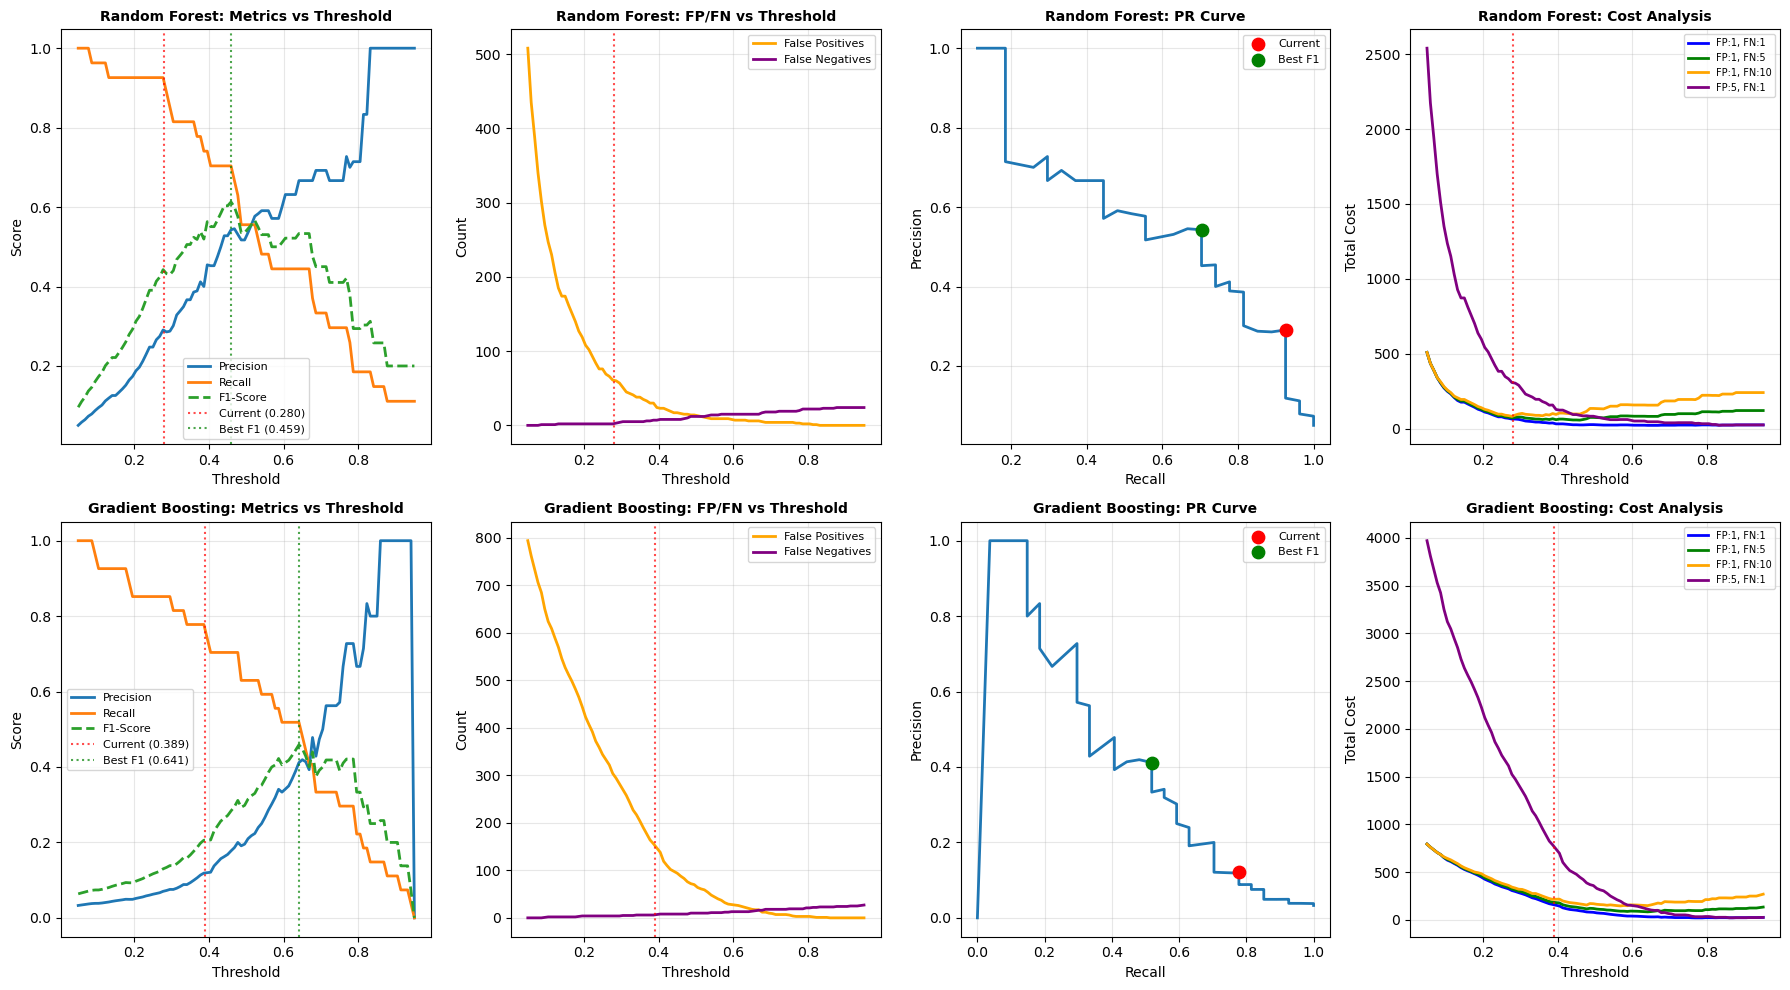

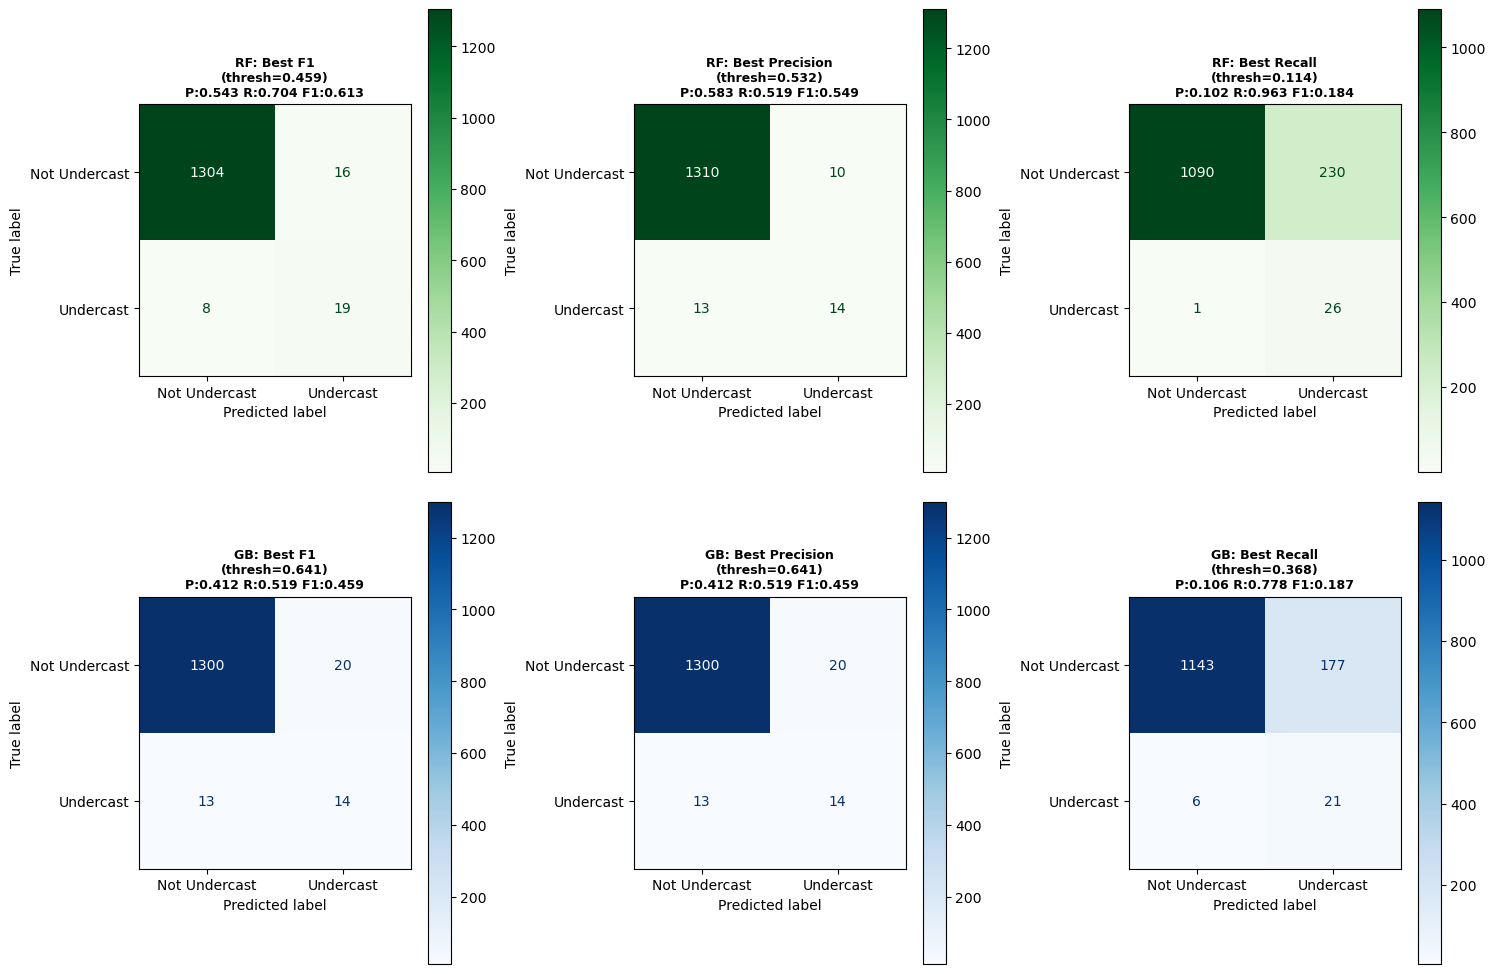


COMPARISON: BEST F1 THRESHOLDS ACROSS MODELS

                   Threshold  Precision    Recall  F1-Score    FP    FN
XGBoost             0.613636   0.800000  0.592593  0.680851   4.0  11.0
Random Forest       0.459091   0.542857  0.703704  0.612903  16.0   8.0
Gradient Boosting   0.640909   0.411765  0.518519  0.459016  20.0  13.0

BEST MODEL BY METRIC (with optimized thresholds)
Best Precision: XGBoost (0.8000)
Best Recall:    Random Forest (0.7037)
Best F1-Score:  XGBoost (0.6809)
Fewest FP:      XGBoost (4)
Fewest FN:      Random Forest (8)


In [95]:
# Decision Threshold Tuning for Random Forest and Gradient Boosting

print("=" * 70)
print("DECISION THRESHOLD TUNING FOR RANDOM FOREST")
print("=" * 70)

# Random Forest threshold tuning
threshold_range = np.linspace(0.05, 0.95, 100)
threshold_results_rf = []

for thresh in threshold_range:
    preds_at_thresh = (preds_rf >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_binary, preds_at_thresh).ravel()
    precision = precision_score(y_test_binary, preds_at_thresh, zero_division=0)
    recall = recall_score(y_test_binary, preds_at_thresh, zero_division=0)
    f1 = f1_score(y_test_binary, preds_at_thresh, zero_division=0)
    
    threshold_results_rf.append({
        'threshold': thresh,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    })

threshold_df_rf = pd.DataFrame(threshold_results_rf)

# Find best thresholds for Random Forest
best_f1_idx_rf = threshold_df_rf['f1_score'].idxmax()
best_precision_idx_rf = threshold_df_rf[threshold_df_rf['recall'] >= 0.5]['precision'].idxmax() if any(threshold_df_rf['recall'] >= 0.5) else 0
best_recall_idx_rf = threshold_df_rf[threshold_df_rf['precision'] >= 0.1]['recall'].idxmax() if any(threshold_df_rf['precision'] >= 0.1) else 0

print("\n" + "=" * 70)
print("RECOMMENDED THRESHOLDS FOR RANDOM FOREST")
print("=" * 70)

print(f"\n1. BEST F1-SCORE (balanced precision/recall):")
print(f"   Threshold: {threshold_df_rf.loc[best_f1_idx_rf, 'threshold']:.4f}")
print(f"   Precision: {threshold_df_rf.loc[best_f1_idx_rf, 'precision']:.4f}")
print(f"   Recall:    {threshold_df_rf.loc[best_f1_idx_rf, 'recall']:.4f}")
print(f"   F1-Score:  {threshold_df_rf.loc[best_f1_idx_rf, 'f1_score']:.4f}")
print(f"   FP: {threshold_df_rf.loc[best_f1_idx_rf, 'fp']:.0f}, FN: {threshold_df_rf.loc[best_f1_idx_rf, 'fn']:.0f}")

print(f"\n2. BEST PRECISION (minimize false alarms, recall >= 50%):")
print(f"   Threshold: {threshold_df_rf.loc[best_precision_idx_rf, 'threshold']:.4f}")
print(f"   Precision: {threshold_df_rf.loc[best_precision_idx_rf, 'precision']:.4f}")
print(f"   Recall:    {threshold_df_rf.loc[best_precision_idx_rf, 'recall']:.4f}")
print(f"   F1-Score:  {threshold_df_rf.loc[best_precision_idx_rf, 'f1_score']:.4f}")
print(f"   FP: {threshold_df_rf.loc[best_precision_idx_rf, 'fp']:.0f}, FN: {threshold_df_rf.loc[best_precision_idx_rf, 'fn']:.0f}")

print(f"\n3. BEST RECALL (catch all undercasts, precision >= 10%):")
print(f"   Threshold: {threshold_df_rf.loc[best_recall_idx_rf, 'threshold']:.4f}")
print(f"   Precision: {threshold_df_rf.loc[best_recall_idx_rf, 'precision']:.4f}")
print(f"   Recall:    {threshold_df_rf.loc[best_recall_idx_rf, 'recall']:.4f}")
print(f"   F1-Score:  {threshold_df_rf.loc[best_recall_idx_rf, 'f1_score']:.4f}")
print(f"   FP: {threshold_df_rf.loc[best_recall_idx_rf, 'fp']:.0f}, FN: {threshold_df_rf.loc[best_recall_idx_rf, 'fn']:.0f}")

print(f"\n4. CURRENT (Youden's Index from ROC):")
print(f"   Threshold: {optimal_threshold_rf:.4f}")
print(f"   Precision: {precision_rf:.4f}")
print(f"   Recall:    {recall_rf:.4f}")
print(f"   F1-Score:  {f1_rf:.4f}")

# Gradient Boosting threshold tuning
print("\n\n" + "=" * 70)
print("DECISION THRESHOLD TUNING FOR GRADIENT BOOSTING")
print("=" * 70)

threshold_results_gb = []

for thresh in threshold_range:
    preds_at_thresh = (preds_smote >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_binary, preds_at_thresh).ravel()
    precision = precision_score(y_test_binary, preds_at_thresh, zero_division=0)
    recall = recall_score(y_test_binary, preds_at_thresh, zero_division=0)
    f1 = f1_score(y_test_binary, preds_at_thresh, zero_division=0)
    
    threshold_results_gb.append({
        'threshold': thresh,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    })

threshold_df_gb = pd.DataFrame(threshold_results_gb)

# Find best thresholds for Gradient Boosting
best_f1_idx_gb = threshold_df_gb['f1_score'].idxmax()
best_precision_idx_gb = threshold_df_gb[threshold_df_gb['recall'] >= 0.5]['precision'].idxmax() if any(threshold_df_gb['recall'] >= 0.5) else 0
best_recall_idx_gb = threshold_df_gb[threshold_df_gb['precision'] >= 0.1]['recall'].idxmax() if any(threshold_df_gb['precision'] >= 0.1) else 0

print("\n" + "=" * 70)
print("RECOMMENDED THRESHOLDS FOR GRADIENT BOOSTING")
print("=" * 70)

print(f"\n1. BEST F1-SCORE (balanced precision/recall):")
print(f"   Threshold: {threshold_df_gb.loc[best_f1_idx_gb, 'threshold']:.4f}")
print(f"   Precision: {threshold_df_gb.loc[best_f1_idx_gb, 'precision']:.4f}")
print(f"   Recall:    {threshold_df_gb.loc[best_f1_idx_gb, 'recall']:.4f}")
print(f"   F1-Score:  {threshold_df_gb.loc[best_f1_idx_gb, 'f1_score']:.4f}")
print(f"   FP: {threshold_df_gb.loc[best_f1_idx_gb, 'fp']:.0f}, FN: {threshold_df_gb.loc[best_f1_idx_gb, 'fn']:.0f}")

print(f"\n2. BEST PRECISION (minimize false alarms, recall >= 50%):")
print(f"   Threshold: {threshold_df_gb.loc[best_precision_idx_gb, 'threshold']:.4f}")
print(f"   Precision: {threshold_df_gb.loc[best_precision_idx_gb, 'precision']:.4f}")
print(f"   Recall:    {threshold_df_gb.loc[best_precision_idx_gb, 'recall']:.4f}")
print(f"   F1-Score:  {threshold_df_gb.loc[best_precision_idx_gb, 'f1_score']:.4f}")
print(f"   FP: {threshold_df_gb.loc[best_precision_idx_gb, 'fp']:.0f}, FN: {threshold_df_gb.loc[best_precision_idx_gb, 'fn']:.0f}")

print(f"\n3. BEST RECALL (catch all undercasts, precision >= 10%):")
print(f"   Threshold: {threshold_df_gb.loc[best_recall_idx_gb, 'threshold']:.4f}")
print(f"   Precision: {threshold_df_gb.loc[best_recall_idx_gb, 'precision']:.4f}")
print(f"   Recall:    {threshold_df_gb.loc[best_recall_idx_gb, 'recall']:.4f}")
print(f"   F1-Score:  {threshold_df_gb.loc[best_recall_idx_gb, 'f1_score']:.4f}")
print(f"   FP: {threshold_df_gb.loc[best_recall_idx_gb, 'fp']:.0f}, FN: {threshold_df_gb.loc[best_recall_idx_gb, 'fn']:.0f}")

print(f"\n4. CURRENT (Youden's Index from ROC):")
print(f"   Threshold: {optimal_threshold_smote:.4f}")
print(f"   Precision: {precision_smote:.4f}")
print(f"   Recall:    {recall_smote:.4f}")
print(f"   F1-Score:  {f1_smote:.4f}")

# Visualizations for both models
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# Row 1: Random Forest
# Plot 1: Precision/Recall vs Threshold
axes[0, 0].plot(threshold_df_rf['threshold'], threshold_df_rf['precision'], label='Precision', linewidth=2)
axes[0, 0].plot(threshold_df_rf['threshold'], threshold_df_rf['recall'], label='Recall', linewidth=2)
axes[0, 0].plot(threshold_df_rf['threshold'], threshold_df_rf['f1_score'], label='F1-Score', linewidth=2, linestyle='--')
axes[0, 0].axvline(optimal_threshold_rf, color='red', linestyle=':', alpha=0.7, label=f'Current ({optimal_threshold_rf:.3f})')
axes[0, 0].axvline(threshold_df_rf.loc[best_f1_idx_rf, 'threshold'], color='green', linestyle=':', alpha=0.7, label=f'Best F1 ({threshold_df_rf.loc[best_f1_idx_rf, "threshold"]:.3f})')
axes[0, 0].set_xlabel('Threshold', fontsize=10)
axes[0, 0].set_ylabel('Score', fontsize=10)
axes[0, 0].set_title('Random Forest: Metrics vs Threshold', fontsize=10, fontweight='bold')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: False Positives/Negatives vs Threshold
axes[0, 1].plot(threshold_df_rf['threshold'], threshold_df_rf['fp'], label='False Positives', linewidth=2, color='orange')
axes[0, 1].plot(threshold_df_rf['threshold'], threshold_df_rf['fn'], label='False Negatives', linewidth=2, color='purple')
axes[0, 1].axvline(optimal_threshold_rf, color='red', linestyle=':', alpha=0.7)
axes[0, 1].set_xlabel('Threshold', fontsize=10)
axes[0, 1].set_ylabel('Count', fontsize=10)
axes[0, 1].set_title('Random Forest: FP/FN vs Threshold', fontsize=10, fontweight='bold')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Precision-Recall Curve
axes[0, 2].plot(threshold_df_rf['recall'], threshold_df_rf['precision'], linewidth=2)
axes[0, 2].scatter(recall_rf, precision_rf, color='red', s=80, zorder=5, label=f'Current')
axes[0, 2].scatter(threshold_df_rf.loc[best_f1_idx_rf, 'recall'], threshold_df_rf.loc[best_f1_idx_rf, 'precision'], 
                   color='green', s=80, zorder=5, label=f'Best F1')
axes[0, 2].set_xlabel('Recall', fontsize=10)
axes[0, 2].set_ylabel('Precision', fontsize=10)
axes[0, 2].set_title('Random Forest: PR Curve', fontsize=10, fontweight='bold')
axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Cost analysis
cost_ratios = [(1, 1), (1, 5), (1, 10), (5, 1)]
colors = ['blue', 'green', 'orange', 'purple']
for (fp_cost, fn_cost), color in zip(cost_ratios, colors):
    total_cost = threshold_df_rf['fp'] * fp_cost + threshold_df_rf['fn'] * fn_cost
    axes[0, 3].plot(threshold_df_rf['threshold'], total_cost, label=f'FP:{fp_cost}, FN:{fn_cost}', 
                    linewidth=2, color=color)
axes[0, 3].axvline(optimal_threshold_rf, color='red', linestyle=':', alpha=0.7)
axes[0, 3].set_xlabel('Threshold', fontsize=10)
axes[0, 3].set_ylabel('Total Cost', fontsize=10)
axes[0, 3].set_title('Random Forest: Cost Analysis', fontsize=10, fontweight='bold')
axes[0, 3].legend(fontsize=7)
axes[0, 3].grid(True, alpha=0.3)

# Row 2: Gradient Boosting
# Plot 1: Precision/Recall vs Threshold
axes[1, 0].plot(threshold_df_gb['threshold'], threshold_df_gb['precision'], label='Precision', linewidth=2)
axes[1, 0].plot(threshold_df_gb['threshold'], threshold_df_gb['recall'], label='Recall', linewidth=2)
axes[1, 0].plot(threshold_df_gb['threshold'], threshold_df_gb['f1_score'], label='F1-Score', linewidth=2, linestyle='--')
axes[1, 0].axvline(optimal_threshold_smote, color='red', linestyle=':', alpha=0.7, label=f'Current ({optimal_threshold_smote:.3f})')
axes[1, 0].axvline(threshold_df_gb.loc[best_f1_idx_gb, 'threshold'], color='green', linestyle=':', alpha=0.7, label=f'Best F1 ({threshold_df_gb.loc[best_f1_idx_gb, "threshold"]:.3f})')
axes[1, 0].set_xlabel('Threshold', fontsize=10)
axes[1, 0].set_ylabel('Score', fontsize=10)
axes[1, 0].set_title('Gradient Boosting: Metrics vs Threshold', fontsize=10, fontweight='bold')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Plot 2: False Positives/Negatives vs Threshold
axes[1, 1].plot(threshold_df_gb['threshold'], threshold_df_gb['fp'], label='False Positives', linewidth=2, color='orange')
axes[1, 1].plot(threshold_df_gb['threshold'], threshold_df_gb['fn'], label='False Negatives', linewidth=2, color='purple')
axes[1, 1].axvline(optimal_threshold_smote, color='red', linestyle=':', alpha=0.7)
axes[1, 1].set_xlabel('Threshold', fontsize=10)
axes[1, 1].set_ylabel('Count', fontsize=10)
axes[1, 1].set_title('Gradient Boosting: FP/FN vs Threshold', fontsize=10, fontweight='bold')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

# Plot 3: Precision-Recall Curve
axes[1, 2].plot(threshold_df_gb['recall'], threshold_df_gb['precision'], linewidth=2)
axes[1, 2].scatter(recall_smote, precision_smote, color='red', s=80, zorder=5, label=f'Current')
axes[1, 2].scatter(threshold_df_gb.loc[best_f1_idx_gb, 'recall'], threshold_df_gb.loc[best_f1_idx_gb, 'precision'], 
                   color='green', s=80, zorder=5, label=f'Best F1')
axes[1, 2].set_xlabel('Recall', fontsize=10)
axes[1, 2].set_ylabel('Precision', fontsize=10)
axes[1, 2].set_title('Gradient Boosting: PR Curve', fontsize=10, fontweight='bold')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

# Plot 4: Cost analysis
for (fp_cost, fn_cost), color in zip(cost_ratios, colors):
    total_cost = threshold_df_gb['fp'] * fp_cost + threshold_df_gb['fn'] * fn_cost
    axes[1, 3].plot(threshold_df_gb['threshold'], total_cost, label=f'FP:{fp_cost}, FN:{fn_cost}', 
                    linewidth=2, color=color)
axes[1, 3].axvline(optimal_threshold_smote, color='red', linestyle=':', alpha=0.7)
axes[1, 3].set_xlabel('Threshold', fontsize=10)
axes[1, 3].set_ylabel('Total Cost', fontsize=10)
axes[1, 3].set_title('Gradient Boosting: Cost Analysis', fontsize=10, fontweight='bold')
axes[1, 3].legend(fontsize=7)
axes[1, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show confusion matrices for different threshold choices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Random Forest confusion matrices
threshold_choices_rf = [
    (best_f1_idx_rf, f'RF: Best F1\n(thresh={threshold_df_rf.loc[best_f1_idx_rf, "threshold"]:.3f})'),
    (best_precision_idx_rf, f'RF: Best Precision\n(thresh={threshold_df_rf.loc[best_precision_idx_rf, "threshold"]:.3f})'),
    (best_recall_idx_rf, f'RF: Best Recall\n(thresh={threshold_df_rf.loc[best_recall_idx_rf, "threshold"]:.3f})')
]

for col, (idx, title) in enumerate(threshold_choices_rf):
    thresh = threshold_df_rf.loc[idx, 'threshold']
    preds_at_thresh = (preds_rf >= thresh).astype(int)
    cm = confusion_matrix(y_test_binary, preds_at_thresh)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Undercast', 'Undercast'])
    disp.plot(ax=axes[0, col], cmap='Greens', values_format='d')
    
    p = threshold_df_rf.loc[idx, 'precision']
    r = threshold_df_rf.loc[idx, 'recall']
    f1 = threshold_df_rf.loc[idx, 'f1_score']
    axes[0, col].set_title(f'{title}\nP:{p:.3f} R:{r:.3f} F1:{f1:.3f}', fontsize=9, fontweight='bold')

# Gradient Boosting confusion matrices
threshold_choices_gb = [
    (best_f1_idx_gb, f'GB: Best F1\n(thresh={threshold_df_gb.loc[best_f1_idx_gb, "threshold"]:.3f})'),
    (best_precision_idx_gb, f'GB: Best Precision\n(thresh={threshold_df_gb.loc[best_precision_idx_gb, "threshold"]:.3f})'),
    (best_recall_idx_gb, f'GB: Best Recall\n(thresh={threshold_df_gb.loc[best_recall_idx_gb, "threshold"]:.3f})')
]

for col, (idx, title) in enumerate(threshold_choices_gb):
    thresh = threshold_df_gb.loc[idx, 'threshold']
    preds_at_thresh = (preds_smote >= thresh).astype(int)
    cm = confusion_matrix(y_test_binary, preds_at_thresh)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Undercast', 'Undercast'])
    disp.plot(ax=axes[1, col], cmap='Blues', values_format='d')
    
    p = threshold_df_gb.loc[idx, 'precision']
    r = threshold_df_gb.loc[idx, 'recall']
    f1 = threshold_df_gb.loc[idx, 'f1_score']
    axes[1, col].set_title(f'{title}\nP:{p:.3f} R:{r:.3f} F1:{f1:.3f}', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Compare best F1 thresholds across all three models
print("\n" + "=" * 70)
print("COMPARISON: BEST F1 THRESHOLDS ACROSS MODELS")
print("=" * 70)

comparison_data = {
    'XGBoost': {
        'Threshold': threshold_df.loc[best_f1_idx, 'threshold'],
        'Precision': threshold_df.loc[best_f1_idx, 'precision'],
        'Recall': threshold_df.loc[best_f1_idx, 'recall'],
        'F1-Score': threshold_df.loc[best_f1_idx, 'f1_score'],
        'FP': int(threshold_df.loc[best_f1_idx, 'fp']),
        'FN': int(threshold_df.loc[best_f1_idx, 'fn'])
    },
    'Random Forest': {
        'Threshold': threshold_df_rf.loc[best_f1_idx_rf, 'threshold'],
        'Precision': threshold_df_rf.loc[best_f1_idx_rf, 'precision'],
        'Recall': threshold_df_rf.loc[best_f1_idx_rf, 'recall'],
        'F1-Score': threshold_df_rf.loc[best_f1_idx_rf, 'f1_score'],
        'FP': int(threshold_df_rf.loc[best_f1_idx_rf, 'fp']),
        'FN': int(threshold_df_rf.loc[best_f1_idx_rf, 'fn'])
    },
    'Gradient Boosting': {
        'Threshold': threshold_df_gb.loc[best_f1_idx_gb, 'threshold'],
        'Precision': threshold_df_gb.loc[best_f1_idx_gb, 'precision'],
        'Recall': threshold_df_gb.loc[best_f1_idx_gb, 'recall'],
        'F1-Score': threshold_df_gb.loc[best_f1_idx_gb, 'f1_score'],
        'FP': int(threshold_df_gb.loc[best_f1_idx_gb, 'fp']),
        'FN': int(threshold_df_gb.loc[best_f1_idx_gb, 'fn'])
    }
}

comparison_df_final = pd.DataFrame(comparison_data).T
print("\n" + comparison_df_final.to_string())

print("\n" + "=" * 70)
print("BEST MODEL BY METRIC (with optimized thresholds)")
print("=" * 70)
print(f"Best Precision: {comparison_df_final['Precision'].idxmax()} ({comparison_df_final['Precision'].max():.4f})")
print(f"Best Recall:    {comparison_df_final['Recall'].idxmax()} ({comparison_df_final['Recall'].max():.4f})")
print(f"Best F1-Score:  {comparison_df_final['F1-Score'].idxmax()} ({comparison_df_final['F1-Score'].max():.4f})")
print(f"Fewest FP:      {comparison_df_final['FP'].idxmin()} ({comparison_df_final['FP'].min():.0f})")
print(f"Fewest FN:      {comparison_df_final['FN'].idxmin()} ({comparison_df_final['FN'].min():.0f})")

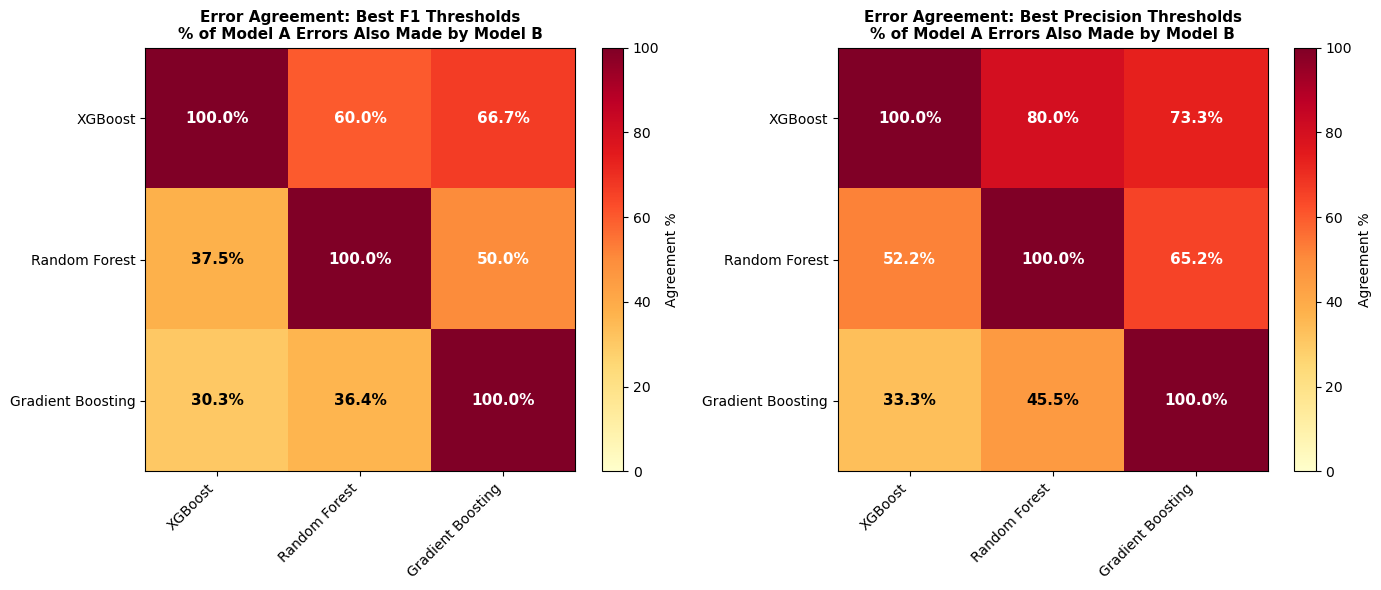

ERROR OVERLAP ANALYSIS: BEST F1 THRESHOLDS

XGBoost:
  Total Errors: 15 (FP: 4, FN: 11)
  → Overlap with Random Forest: 9 errors (60.0%)
  → Overlap with Gradient Boosting: 10 errors (66.7%)

Random Forest:
  Total Errors: 24 (FP: 16, FN: 8)
  → Overlap with XGBoost: 9 errors (37.5%)
  → Overlap with Gradient Boosting: 12 errors (50.0%)

Gradient Boosting:
  Total Errors: 33 (FP: 20, FN: 13)
  → Overlap with XGBoost: 10 errors (30.3%)
  → Overlap with Random Forest: 12 errors (36.4%)

ERROR OVERLAP ANALYSIS: BEST PRECISION THRESHOLDS

XGBoost:
  Total Errors: 15 (FP: 2, FN: 13)
  → Overlap with Random Forest: 12 errors (80.0%)
  → Overlap with Gradient Boosting: 11 errors (73.3%)

Random Forest:
  Total Errors: 23 (FP: 10, FN: 13)
  → Overlap with XGBoost: 12 errors (52.2%)
  → Overlap with Gradient Boosting: 15 errors (65.2%)

Gradient Boosting:
  Total Errors: 33 (FP: 20, FN: 13)
  → Overlap with XGBoost: 11 errors (33.3%)
  → Overlap with Random Forest: 15 errors (45.5%)

MODEL AGRE

In [96]:
# Error Agreement Analysis for Optimized Thresholds

# Get predictions at best F1 thresholds
preds_xgb_best_f1 = (preds_xgb >= threshold_df.loc[best_f1_idx, 'threshold']).astype(int)
preds_rf_best_f1 = (preds_rf >= threshold_df_rf.loc[best_f1_idx_rf, 'threshold']).astype(int)
preds_gb_best_f1 = (preds_smote >= threshold_df_gb.loc[best_f1_idx_gb, 'threshold']).astype(int)

# Get predictions at best precision thresholds
preds_xgb_best_prec = (preds_xgb >= threshold_df.loc[best_precision_idx, 'threshold']).astype(int)
preds_rf_best_prec = (preds_rf >= threshold_df_rf.loc[best_precision_idx_rf, 'threshold']).astype(int)
preds_gb_best_prec = (preds_smote >= threshold_df_gb.loc[best_precision_idx_gb, 'threshold']).astype(int)

model_names_optimized = ['XGBoost', 'Random Forest', 'Gradient Boosting']

# Create error analysis DataFrames
error_analysis_f1 = pd.DataFrame({'True_Label': y_test_binary.values})
error_analysis_prec = pd.DataFrame({'True_Label': y_test_binary.values})

# Best F1 predictions
for model_name, preds in zip(model_names_optimized, [preds_xgb_best_f1, preds_rf_best_f1, preds_gb_best_f1]):
    error_analysis_f1[f'{model_name}_Pred'] = preds
    error_analysis_f1[f'{model_name}_Correct'] = (preds == y_test_binary.values).astype(int)

# Best Precision predictions
for model_name, preds in zip(model_names_optimized, [preds_xgb_best_prec, preds_rf_best_prec, preds_gb_best_prec]):
    error_analysis_prec[f'{model_name}_Pred'] = preds
    error_analysis_prec[f'{model_name}_Correct'] = (preds == y_test_binary.values).astype(int)

# Calculate error agreement matrices
def calculate_error_agreement(error_df, model_names):
    n_models = len(model_names)
    error_agreement = np.zeros((n_models, n_models))
    
    for i, model1 in enumerate(model_names):
        for j, model2 in enumerate(model_names):
            if i == j:
                error_agreement[i, j] = 100.0
            else:
                errors1 = set(error_df[error_df[f'{model1}_Correct'] == 0].index)
                errors2 = set(error_df[error_df[f'{model2}_Correct'] == 0].index)
                if len(errors1) > 0:
                    overlap_pct = 100 * len(errors1 & errors2) / len(errors1)
                    error_agreement[i, j] = overlap_pct
    
    return error_agreement

error_agreement_f1 = calculate_error_agreement(error_analysis_f1, model_names_optimized)
error_agreement_prec = calculate_error_agreement(error_analysis_prec, model_names_optimized)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Best F1 Error Agreement
im1 = axes[0].imshow(error_agreement_f1, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
axes[0].set_xticks(range(len(model_names_optimized)))
axes[0].set_yticks(range(len(model_names_optimized)))
axes[0].set_xticklabels(model_names_optimized, rotation=45, ha='right', fontsize=10)
axes[0].set_yticklabels(model_names_optimized, fontsize=10)
axes[0].set_title('Error Agreement: Best F1 Thresholds\n% of Model A Errors Also Made by Model B', 
                  fontsize=11, fontweight='bold')

# Add text annotations
for i in range(len(model_names_optimized)):
    for j in range(len(model_names_optimized)):
        text = axes[0].text(j, i, f'{error_agreement_f1[i, j]:.1f}%',
                           ha="center", va="center", 
                           color="black" if error_agreement_f1[i, j] < 50 else "white", 
                           fontsize=11, fontweight='bold')

plt.colorbar(im1, ax=axes[0], label='Agreement %')

# Plot 2: Best Precision Error Agreement
im2 = axes[1].imshow(error_agreement_prec, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
axes[1].set_xticks(range(len(model_names_optimized)))
axes[1].set_yticks(range(len(model_names_optimized)))
axes[1].set_xticklabels(model_names_optimized, rotation=45, ha='right', fontsize=10)
axes[1].set_yticklabels(model_names_optimized, fontsize=10)
axes[1].set_title('Error Agreement: Best Precision Thresholds\n% of Model A Errors Also Made by Model B', 
                  fontsize=11, fontweight='bold')

# Add text annotations
for i in range(len(model_names_optimized)):
    for j in range(len(model_names_optimized)):
        text = axes[1].text(j, i, f'{error_agreement_prec[i, j]:.1f}%',
                           ha="center", va="center", 
                           color="black" if error_agreement_prec[i, j] < 50 else "white", 
                           fontsize=11, fontweight='bold')

plt.colorbar(im2, ax=axes[1], label='Agreement %')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("=" * 70)
print("ERROR OVERLAP ANALYSIS: BEST F1 THRESHOLDS")
print("=" * 70)

for i, model1 in enumerate(model_names_optimized):
    errors1 = set(error_analysis_f1[error_analysis_f1[f'{model1}_Correct'] == 0].index)
    fp1 = set(error_analysis_f1[(error_analysis_f1[f'{model1}_Pred'] == 1) & (error_analysis_f1['True_Label'] == 0)].index)
    fn1 = set(error_analysis_f1[(error_analysis_f1[f'{model1}_Pred'] == 0) & (error_analysis_f1['True_Label'] == 1)].index)
    
    print(f"\n{model1}:")
    print(f"  Total Errors: {len(errors1)} (FP: {len(fp1)}, FN: {len(fn1)})")
    
    for j, model2 in enumerate(model_names_optimized):
        if i != j:
            errors2 = set(error_analysis_f1[error_analysis_f1[f'{model2}_Correct'] == 0].index)
            overlap = errors1 & errors2
            print(f"  → Overlap with {model2}: {len(overlap)} errors ({100*len(overlap)/len(errors1):.1f}%)")

print("\n" + "=" * 70)
print("ERROR OVERLAP ANALYSIS: BEST PRECISION THRESHOLDS")
print("=" * 70)

for i, model1 in enumerate(model_names_optimized):
    errors1 = set(error_analysis_prec[error_analysis_prec[f'{model1}_Correct'] == 0].index)
    fp1 = set(error_analysis_prec[(error_analysis_prec[f'{model1}_Pred'] == 1) & (error_analysis_prec['True_Label'] == 0)].index)
    fn1 = set(error_analysis_prec[(error_analysis_prec[f'{model1}_Pred'] == 0) & (error_analysis_prec['True_Label'] == 1)].index)
    
    print(f"\n{model1}:")
    print(f"  Total Errors: {len(errors1)} (FP: {len(fp1)}, FN: {len(fn1)})")
    
    for j, model2 in enumerate(model_names_optimized):
        if i != j:
            errors2 = set(error_analysis_prec[error_analysis_prec[f'{model2}_Correct'] == 0].index)
            overlap = errors1 & errors2
            print(f"  → Overlap with {model2}: {len(overlap)} errors ({100*len(overlap)/len(errors1):.1f}%)")

# Count samples where all models agree/disagree
print("\n" + "=" * 70)
print("MODEL AGREEMENT SUMMARY")
print("=" * 70)

for df, threshold_type in [(error_analysis_f1, "Best F1"), (error_analysis_prec, "Best Precision")]:
    correct_counts = df[[f'{m}_Correct' for m in model_names_optimized]].sum(axis=1)
    
    all_correct = correct_counts == 3
    two_correct = correct_counts == 2
    one_correct = correct_counts == 1
    all_error = correct_counts == 0
    
    print(f"\n{threshold_type} Thresholds:")
    print(f"  All 3 models correct:  {all_correct.sum():4d} samples ({100*all_correct.sum()/len(df):.1f}%)")
    print(f"  2 models correct:      {two_correct.sum():4d} samples ({100*two_correct.sum()/len(df):.1f}%)")
    print(f"  1 model correct:       {one_correct.sum():4d} samples ({100*one_correct.sum()/len(df):.1f}%)")
    print(f"  All 3 models wrong:    {all_error.sum():4d} samples ({100*all_error.sum()/len(df):.1f}%)")

In [97]:
# Extract month/day/hour (fxx) from test data for error analysis
print("\n" + "=" * 70)
print("ERRORS BY DATE: BEST F1 THRESHOLDS")
print("=" * 70)

# Helper to format date + fxx
def _fmt_date_fxx(idx):
    # Year
    try:
        if 'year' in X_test.columns:
            year = int(X_test.iloc[idx]['year'])
        else:
            name = X_test.iloc[idx].name
            year = int(name.split('-')[0]) if isinstance(name, str) and name[:4].isdigit() else 2024
    except Exception:
        year = 2024
    # Month/Day
    month = int(X_test.iloc[idx]['month']) if 'month' in X_test.columns else 0
    day = int(X_test.iloc[idx]['day']) if 'day' in X_test.columns else 0
    # fxx hour
    try:
        fxx = int(X_test.iloc[idx]['fxx']) if 'fxx' in X_test.columns else None
    except Exception:
        fxx = None
    fxx_str = f"{fxx:02d}" if isinstance(fxx, (int, np.integer)) else "--"
    return f"{year}/{month:02d}/{day:02d}  {fxx_str}"

# For each model, show where it made errors
for model_name, preds in zip(model_names_optimized, [preds_xgb_best_f1, preds_rf_best_f1, preds_gb_best_f1]):
    errors_idx = set(error_analysis_f1[error_analysis_f1[f'{model_name}_Correct'] == 0].index)
    
    if errors_idx:
        print(f"\n{model_name} - {len(errors_idx)} errors:")
        
        # Get FP and FN separately
        fp_idx = set(error_analysis_f1[(error_analysis_f1[f'{model_name}_Pred'] == 1) & 
                                       (error_analysis_f1['True_Label'] == 0)].index)
        fn_idx = set(error_analysis_f1[(error_analysis_f1[f'{model_name}_Pred'] == 0) & 
                                       (error_analysis_f1['True_Label'] == 1)].index)
        
        # Collect date+hour strings
        error_dates = []
        for idx in sorted(errors_idx):
            error_type = 'FP' if idx in fp_idx else 'FN'
            error_dates.append((_fmt_date_fxx(idx), error_type))
        
        # Sort by date string
        error_dates.sort(key=lambda x: x[0])
        
        # Print one per line, with type
        for dstr, error_type in error_dates:
            print(f"  {dstr} ({error_type})")

print("\n" + "=" * 70)
print("ERRORS BY DATE: BEST PRECISION THRESHOLDS")
print("=" * 70)

# Same analysis for best precision thresholds
for model_name, preds in zip(model_names_optimized, [preds_xgb_best_prec, preds_rf_best_prec, preds_gb_best_prec]):
    errors_idx = set(error_analysis_prec[error_analysis_prec[f'{model_name}_Correct'] == 0].index)
    
    if errors_idx:
        print(f"\n{model_name} - {len(errors_idx)} errors:")
        
        # Get FP and FN separately
        fp_idx = set(error_analysis_prec[(error_analysis_prec[f'{model_name}_Pred'] == 1) & 
                                         (error_analysis_prec['True_Label'] == 0)].index)
        fn_idx = set(error_analysis_prec[(error_analysis_prec[f'{model_name}_Pred'] == 0) & 
                                         (error_analysis_prec['True_Label'] == 1)].index)
        
        # Collect date+hour strings
        error_dates = []
        for idx in sorted(errors_idx):
            error_type = 'FP' if idx in fp_idx else 'FN'
            error_dates.append((_fmt_date_fxx(idx), error_type))
        
        error_dates.sort(key=lambda x: x[0])
        for dstr, error_type in error_dates:
            print(f"  {dstr} ({error_type})")


ERRORS BY DATE: BEST F1 THRESHOLDS

XGBoost - 15 errors:
  2024/02/22  -- (FP)
  2024/07/20  -- (FP)
  2024/09/06  -- (FN)
  2024/09/22  -- (FN)
  2024/09/22  -- (FN)
  2024/10/02  -- (FN)
  2024/10/06  -- (FN)
  2024/10/06  -- (FN)
  2024/10/06  -- (FN)
  2024/10/21  -- (FN)
  2024/10/28  -- (FN)
  2024/10/28  -- (FN)
  2024/11/02  -- (FN)
  2024/11/09  -- (FP)
  2024/12/16  -- (FP)

Random Forest - 24 errors:
  2024/01/18  -- (FN)
  2024/02/22  -- (FP)
  2024/07/21  -- (FP)
  2024/09/10  -- (FP)
  2024/09/15  -- (FP)
  2024/09/22  -- (FN)
  2024/09/22  -- (FN)
  2024/09/22  -- (FP)
  2024/10/02  -- (FN)
  2024/10/03  -- (FP)
  2024/10/08  -- (FP)
  2024/10/11  -- (FP)
  2024/10/15  -- (FP)
  2024/10/16  -- (FP)
  2024/10/17  -- (FP)
  2024/10/21  -- (FN)
  2024/10/27  -- (FP)
  2024/10/28  -- (FN)
  2024/10/28  -- (FN)
  2024/11/02  -- (FN)
  2024/11/03  -- (FP)
  2024/11/09  -- (FP)
  2024/11/21  -- (FP)
  2024/11/21  -- (FP)

Gradient Boosting - 33 errors:
  2024/01/18  -- (FN)
  

In [98]:
# Agreement breakdown: categorize FP/FN across correctness groups with dates + fxx
from collections import defaultdict

def _get_date_hour_str(idx):
    try:
        if 'year' in X_test.columns:
            year = int(X_test.iloc[idx]['year'])
        else:
            name = X_test.iloc[idx].name
            year = int(name.split('-')[0]) if isinstance(name, str) and name[:4].isdigit() else 2024
    except Exception:
        year = 2024
    month = int(X_test.iloc[idx]['month']) if 'month' in X_test.columns else 0
    day = int(X_test.iloc[idx]['day']) if 'day' in X_test.columns else 0
    try:
        fxx = int(X_test.iloc[idx]['fxx']) if 'fxx' in X_test.columns else None
    except Exception:
        fxx = None
    fxx_str = f"{fxx:02d}" if isinstance(fxx, (int, np.integer)) else "--"
    return f"{year}/{month:02d}/{day:02d}  {fxx_str}"

def summarize_agreement_breakdown(error_df, model_names, threshold_label):
    print("\n" + "=" * 70)
    print(f"AGREEMENT BREAKDOWN ({threshold_label})")
    print("=" * 70)

    correct_cols = [f"{m}_Correct" for m in model_names]
    pred_cols = [f"{m}_Pred" for m in model_names]

    correct_counts = error_df[correct_cols].sum(axis=1)

    all_correct_mask = correct_counts == len(model_names)
    one_wrong_mask   = correct_counts == len(model_names) - 1
    two_wrong_mask   = correct_counts == 1
    all_error_mask   = correct_counts == 0

    # All wrong: split into all FP vs all FN and list dates
    all_wrong = error_df[all_error_mask]
    all_wrong_fp_idx = all_wrong[(all_wrong['True_Label'] == 0) & (all_wrong[pred_cols].sum(axis=1) == len(model_names))].index.tolist()
    all_wrong_fn_idx = all_wrong[(all_wrong['True_Label'] == 1) & (all_wrong[pred_cols].sum(axis=1) == 0)].index.tolist()

    print(f"All 3 wrong: {len(all_wrong):4d} samples")
    print(f"  - All FP: {len(all_wrong_fp_idx):4d}")
    if all_wrong_fp_idx:
        dates = sorted(_get_date_hour_str(i) for i in all_wrong_fp_idx)
        for d in dates:
            print(f"      • {d}")
    print(f"  - All FN: {len(all_wrong_fn_idx):4d}")
    if all_wrong_fn_idx:
        dates = sorted(_get_date_hour_str(i) for i in all_wrong_fn_idx)
        for d in dates:
            print(f"      • {d}")

    # One wrong (2 correct): per-model FP/FN counts with dates
    one_wrong = error_df[one_wrong_mask]
    per_model_counts = {m: {'FP': 0, 'FN': 0} for m in model_names}
    per_model_dates = {m: {'FP': [], 'FN': []} for m in model_names}

    for idx, row in one_wrong.iterrows():
        true = row['True_Label']
        for m in model_names:
            if row[f'{m}_Correct'] == 0:
                pred = row[f'{m}_Pred']
                error_type = 'FP' if (true == 0 and pred == 1) else 'FN'
                per_model_counts[m][error_type] += 1
                per_model_dates[m][error_type].append(_get_date_hour_str(idx))
                break
    print(f"\nOne wrong (2 correct): {len(one_wrong):4d} samples")
    total_fp = sum(d['FP'] for d in per_model_counts.values())
    total_fn = sum(d['FN'] for d in per_model_counts.values())
    print(f"  - Total FP: {total_fp:4d} | Total FN: {total_fn:4d}")
    for m in model_names:
        print(f"  - {m}: FP {per_model_counts[m]['FP']:4d}, FN {per_model_counts[m]['FN']:4d}")
        if per_model_dates[m]['FP']:
            for d in sorted(per_model_dates[m]['FP']):
                print(f"      • FP: {d}")
        if per_model_dates[m]['FN']:
            for d in sorted(per_model_dates[m]['FN']):
                print(f"      • FN: {d}")

    # Two wrong (1 correct): per-pair FP/FN counts with dates
    two_wrong = error_df[two_wrong_mask]
    pair_counts = defaultdict(lambda: {'FP': 0, 'FN': 0})
    pair_dates = defaultdict(lambda: {'FP': [], 'FN': []})

    for idx, row in two_wrong.iterrows():
        true = row['True_Label']
        wrong_models = [m for m in model_names if row[f'{m}_Correct'] == 0]
        key = ' + '.join(sorted(wrong_models))
        error_type = 'FP' if true == 0 else 'FN'
        pair_counts[key][error_type] += 1
        pair_dates[key][error_type].append(_get_date_hour_str(idx))

    print(f"\nTwo wrong (1 correct): {len(two_wrong):4d} samples")
    total_fp = sum(d['FP'] for d in pair_counts.values())
    total_fn = sum(d['FN'] for d in pair_counts.values())
    print(f"  - Total FP: {total_fp:4d} | Total FN: {total_fn:4d}")
    for pair in sorted(pair_counts.keys()):
        print(f"  - {pair}: FP {pair_counts[pair]['FP']:4d}, FN {pair_counts[pair]['FN']:4d}")
        if pair_dates[pair]['FP']:
            for d in sorted(pair_dates[pair]['FP']):
                print(f"      • FP: {d}")
        if pair_dates[pair]['FN']:
            for d in sorted(pair_dates[pair]['FN']):
                print(f"      • FN: {d}")

    # All correct: just report count
    print(f"\nAll 3 correct: {int(all_correct_mask.sum()):4d} samples")

# Run breakdown for both threshold selections
summarize_agreement_breakdown(error_analysis_f1, model_names_optimized, 'Best F1')
summarize_agreement_breakdown(error_analysis_prec, model_names_optimized, 'Best Precision')


AGREEMENT BREAKDOWN (Best F1)
All 3 wrong:    7 samples
  - All FP:    1
      • 2024/02/22  --
  - All FN:    6
      • 2024/09/22  --
      • 2024/09/22  --
      • 2024/10/02  --
      • 2024/10/21  --
      • 2024/10/28  --
      • 2024/10/28  --

One wrong (2 correct):   31 samples
  - Total FP:   27 | Total FN:    4
  - XGBoost: FP    2, FN    1
      • FP: 2024/07/20  --
      • FP: 2024/12/16  --
      • FN: 2024/09/06  --
  - Random Forest: FP   10, FN    0
      • FP: 2024/07/21  --
      • FP: 2024/09/22  --
      • FP: 2024/10/03  --
      • FP: 2024/10/08  --
      • FP: 2024/10/11  --
      • FP: 2024/10/16  --
      • FP: 2024/10/17  --
      • FP: 2024/10/27  --
      • FP: 2024/11/03  --
      • FP: 2024/11/21  --
  - Gradient Boosting: FP   15, FN    3
      • FP: 2024/07/23  --
      • FP: 2024/08/18  --
      • FP: 2024/08/21  --
      • FP: 2024/09/10  --
      • FP: 2024/09/30  --
      • FP: 2024/09/30  --
      • FP: 2024/11/07  --
      • FP: 2024/11/09  --
  

In [100]:
# Save trained models and preprocessing pipeline for later use
import joblib
import json

# Define output directory
model_output_dir = "/Users/lucasehinger/Library/CloudStorage/OneDrive-Personal/Documents/MIT/lucasehinger.github.io/files/weather/models/"
os.makedirs(model_output_dir, exist_ok=True)

# Save preprocessing pipeline (needed to transform new data)
joblib.dump(preprocess, os.path.join(model_output_dir, 'preprocessor.pkl'))
print(f"✓ Saved preprocessor to {model_output_dir}preprocessor.pkl")

# Save XGBoost model
xgb.save_model(os.path.join(model_output_dir, 'xgboost_best_f1.json'))
print(f"✓ Saved XGBoost model to {model_output_dir}xgboost_best_f1.json")

# Save Random Forest model
joblib.dump(rf, os.path.join(model_output_dir, 'random_forest_best_f1.pkl'))
print(f"✓ Saved Random Forest model to {model_output_dir}random_forest_best_f1.pkl")

# Save Gradient Boosting model (SMOTE version)
joblib.dump(model_smote, os.path.join(model_output_dir, 'gradient_boosting_best_f1.pkl'))
print(f"✓ Saved Gradient Boosting model to {model_output_dir}gradient_boosting_best_f1.pkl")

# Save optimal thresholds and metadata
model_metadata = {
    'XGBoost': {
        'threshold_best_f1': float(threshold_df.loc[best_f1_idx, 'threshold']),
        'precision': float(threshold_df.loc[best_f1_idx, 'precision']),
        'recall': float(threshold_df.loc[best_f1_idx, 'recall']),
        'f1_score': float(threshold_df.loc[best_f1_idx, 'f1_score']),
        'fp': int(threshold_df.loc[best_f1_idx, 'fp']),
        'fn': int(threshold_df.loc[best_f1_idx, 'fn'])
    },
    'Random Forest': {
        'threshold_best_f1': float(threshold_df_rf.loc[best_f1_idx_rf, 'threshold']),
        'precision': float(threshold_df_rf.loc[best_f1_idx_rf, 'precision']),
        'recall': float(threshold_df_rf.loc[best_f1_idx_rf, 'recall']),
        'f1_score': float(threshold_df_rf.loc[best_f1_idx_rf, 'f1_score']),
        'fp': int(threshold_df_rf.loc[best_f1_idx_rf, 'fp']),
        'fn': int(threshold_df_rf.loc[best_f1_idx_rf, 'fn'])
    },
    'Gradient Boosting': {
        'threshold_best_f1': float(threshold_df_gb.loc[best_f1_idx_gb, 'threshold']),
        'precision': float(threshold_df_gb.loc[best_f1_idx_gb, 'precision']),
        'recall': float(threshold_df_gb.loc[best_f1_idx_gb, 'recall']),
        'f1_score': float(threshold_df_gb.loc[best_f1_idx_gb, 'f1_score']),
        'fp': int(threshold_df_gb.loc[best_f1_idx_gb, 'fp']),
        'fn': int(threshold_df_gb.loc[best_f1_idx_gb, 'fn'])
    },
    'feature_columns': model_cols,
    'categorical_columns': cat_cols,
    'numerical_columns': num_cols,
    'target_column': target_col,
    'random_state': random_state
}

with open(os.path.join(model_output_dir, 'model_metadata.json'), 'w') as f:
    json.dump(model_metadata, f, indent=2)
print(f"✓ Saved model metadata to {model_output_dir}model_metadata.json")

print("\n" + "=" * 70)
print("MODEL SAVING COMPLETE")
print("=" * 70)
print(f"\nSaved files in: {model_output_dir}")
print("\nTo load and use these models in another script:")
print("""
import joblib
import xgboost as xgb
import json

# Load preprocessing pipeline
preprocess = joblib.load('preprocessor.pkl')

# Load models
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('xgboost_best_f1.json')
rf_model = joblib.load('random_forest_best_f1.pkl')
gb_model = joblib.load('gradient_boosting_best_f1.pkl')

# Load metadata (thresholds, etc.)
with open('model_metadata.json') as f:
    metadata = json.load(f)

# Make predictions with optimal threshold
X_new_preprocessed = preprocess.transform(X_new)
xgb_proba = xgb_model.predict_proba(X_new_preprocessed)[:, 1]
xgb_pred = (xgb_proba >= metadata['XGBoost']['threshold_best_f1']).astype(int)
""")

✓ Saved preprocessor to /Users/lucasehinger/Library/CloudStorage/OneDrive-Personal/Documents/MIT/lucasehinger.github.io/files/weather/models/preprocessor.pkl
✓ Saved XGBoost model to /Users/lucasehinger/Library/CloudStorage/OneDrive-Personal/Documents/MIT/lucasehinger.github.io/files/weather/models/xgboost_best_f1.json
✓ Saved Random Forest model to /Users/lucasehinger/Library/CloudStorage/OneDrive-Personal/Documents/MIT/lucasehinger.github.io/files/weather/models/random_forest_best_f1.pkl
✓ Saved Gradient Boosting model to /Users/lucasehinger/Library/CloudStorage/OneDrive-Personal/Documents/MIT/lucasehinger.github.io/files/weather/models/gradient_boosting_best_f1.pkl
✓ Saved model metadata to /Users/lucasehinger/Library/CloudStorage/OneDrive-Personal/Documents/MIT/lucasehinger.github.io/files/weather/models/model_metadata.json

MODEL SAVING COMPLETE

Saved files in: /Users/lucasehinger/Library/CloudStorage/OneDrive-Personal/Documents/MIT/lucasehinger.github.io/files/weather/models/

T